# Предобработка данных

На этом этапе проводится первичный анализ и подготовка исходного датасета к обучению моделей.

Основные задачи:
- проверить структуру и качество данных;
- определить целевые и служебные признаки;
- исследовать пропуски и типы данных;
- исключить возможную утечку целевой информации;
- сформировать итоговую матрицу признаков `X`.


## 1. Загрузка данных

Загружаем исходный датасет из `data/raw` и проверяем его размер и первые строки. Исходный файл на этом этапе не изменяется.


In [6]:
import pandas as pd
import numpy as np

DATA_PATH = "../data/raw/deficiency_anemia.csv"

df = pd.read_csv(DATA_PATH)

print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
display(df.head())

Размер датасета: (840, 48)

Первые 5 строк:


,patient_id,age_years,sex,hemoglobin,RBC,hematocrit,MCV,MCH,MCHC,RDW,...,anemia,iron_deficiency,B12_deficiency,folate_deficiency,B6_deficiency,copper_deficiency,inflammation_anemia,mixed_deficiency,anemia_class,deficiency_cause
0,P000001,64,M,139.6,4.99,41.8,83.3,28.0,332.5,13.3,...,0,0,1,0,0,0,0,0,B12_deficiency_no_anemia,B12_deficiency
1,P000002,52,F,122.3,3.87,35.5,90.0,31.6,343.7,19.8,...,0,0,0,1,0,0,0,0,folate_deficiency_no_anemia,folate_deficiency
2,P000003,43,F,144.9,5.20,44.6,86.1,27.9,329.2,14.7,...,0,1,0,0,0,0,0,0,latent_deficiency,iron_deficiency
3,P000004,26,F,121.7,4.46,39.0,86.9,27.3,316.2,16.7,...,0,0,1,0,0,0,0,0,B12_deficiency_no_anemia,B12_deficiency
4,P000005,30,F,111.5,2.98,32.5,109.1,37.5,341.6,19.7,...,1,0,1,0,0,0,0,0,B12_deficiency_anemia,B12_deficiency


## 2. Проверка структуры датасета

Изучаем типы данных, количество заполненных значений и названия столбцов. Это помогает понять структуру исходных данных перед дальнейшей обработкой.


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 48 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           840 non-null    object 
 1   age_years            840 non-null    int64  
 2   sex                  840 non-null    object 
 3   hemoglobin           840 non-null    float64
 4   RBC                  840 non-null    float64
 5   hematocrit           840 non-null    float64
 6   MCV                  840 non-null    float64
 7   MCH                  840 non-null    float64
 8   MCHC                 840 non-null    float64
 9   RDW                  825 non-null    float64
 10  platelets            840 non-null    int64  
 11  WBC                  840 non-null    float64
 12  reticulocytes        401 non-null    float64
 13  ferritin             594 non-null    float64
 14  serum_iron           540 non-null    float64
 15  transferrin          540 non-null    flo

In [8]:
df.columns.tolist()

['patient_id',
 'age_years',
 'sex',
 'hemoglobin',
 'RBC',
 'hematocrit',
 'MCV',
 'MCH',
 'MCHC',
 'RDW',
 'platelets',
 'WBC',
 'reticulocytes',
 'ferritin',
 'serum_iron',
 'transferrin',
 'TIBC',
 'UIBC',
 'TSAT',
 'sTfR',
 'Ret_He',
 'vitamin_B12',
 'active_B12',
 'MMA',
 'homocysteine',
 'folate',
 'vitamin_B6',
 'copper',
 'ceruloplasmin',
 'CRP',
 'ESR',
 'creatinine',
 'eGFR',
 'TSH',
 'albumin',
 'LDH',
 'indirect_bilirubin',
 'haptoglobin',
 'anemia',
 'iron_deficiency',
 'B12_deficiency',
 'folate_deficiency',
 'B6_deficiency',
 'copper_deficiency',
 'inflammation_anemia',
 'mixed_deficiency',
 'anemia_class',
 'deficiency_cause']

## 3. Проверка пациентов

Проверяем количество уникальных пациентов и наличие повторяющихся `patient_id`. Это важно для корректного последующего разделения данных.


In [9]:
df["patient_id"].nunique()

840

In [10]:
df["patient_id"].duplicated().sum()

np.int64(0)

## 4. Анализ целевого класса

Проверяем распределение и количество значений `anemia_class`. Этот признак будет использоваться как основная целевая переменная многоклассовой классификации.


In [11]:
df["anemia_class"].value_counts(dropna=False)

anemia_class
mixed_deficiency               115
iron_deficiency_anemia         115
no_anemia_no_deficiency        110
latent_deficiency               85
anemia_other                    75
inflammation_anemia             65
B12_deficiency_anemia           65
B12_deficiency_no_anemia        50
folate_deficiency_anemia        50
folate_deficiency_no_anemia     40
copper_deficiency               35
B6_deficiency                   35
Name: count, dtype: int64

In [12]:
df["anemia_class"].nunique()

12

## 5. Целевые и идентификационные колонки

Отдельно фиксируем целевые признаки и идентификатор пациента. Эти столбцы не должны попадать в матрицу входных признаков модели, чтобы избежать утечки целевой информации (`data leakage`).


In [13]:
TARGET_COLUMNS = [
    "anemia",
    "iron_deficiency",
    "B12_deficiency",
    "folate_deficiency",
    "B6_deficiency",
    "copper_deficiency",
    "inflammation_anemia",
    "mixed_deficiency",
    "anemia_class",
    "deficiency_cause",
]

ID_COLUMNS = [
    "patient_id",
]

## 6. Первичная проверка типов и пропусков

Смотрим типы всех колонок и долю отсутствующих значений. На этом этапе пропуски не заполняются и строки не удаляются.


In [14]:
df.dtypes

patient_id              object
age_years                int64
sex                     object
hemoglobin             float64
RBC                    float64
hematocrit             float64
MCV                    float64
MCH                    float64
MCHC                   float64
RDW                    float64
platelets                int64
WBC                    float64
reticulocytes          float64
ferritin               float64
serum_iron             float64
transferrin            float64
TIBC                   float64
UIBC                   float64
TSAT                   float64
sTfR                   float64
Ret_He                 float64
vitamin_B12            float64
active_B12             float64
MMA                    float64
homocysteine           float64
folate                 float64
vitamin_B6             float64
copper                 float64
ceruloplasmin          float64
CRP                    float64
ESR                    float64
creatinine             float64
eGFR    

In [15]:
missing_percent = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing_percent

copper                 85.238095
ceruloplasmin          84.404762
vitamin_B6             83.928571
Ret_He                 73.095238
sTfR                   70.000000
active_B12             70.000000
MMA                    67.619048
homocysteine           64.523810
LDH                    61.309524
indirect_bilirubin     61.309524
haptoglobin            58.809524
reticulocytes          52.261905
TSH                    49.404762
folate                 45.833333
ESR                    41.428571
CRP                    40.952381
vitamin_B12            38.928571
TIBC                   35.714286
UIBC                   35.714286
TSAT                   35.714286
serum_iron             35.714286
transferrin            35.714286
eGFR                   35.595238
creatinine             35.595238
albumin                35.238095
ferritin               29.285714
RDW                     1.785714
patient_id              0.000000
age_years               0.000000
sex                     0.000000
MCV       

## 7. Проверка целевых признаков

Убеждаемся, что все ожидаемые целевые и идентификационные колонки присутствуют в датасете, после чего рассматриваем реальные значения целевых переменных.


In [16]:
missing_targets = [
    col for col in TARGET_COLUMNS
    if col not in df.columns
]

missing_ids = [
    col for col in ID_COLUMNS
    if col not in df.columns
]

print("Отсутствующие target-колонки:", missing_targets)
print("Отсутствующие ID-колонки:", missing_ids)

Отсутствующие target-колонки: []
Отсутствующие ID-колонки: []


In [17]:
for col in TARGET_COLUMNS:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- anemia ---
anemia
1    531
0    309
Name: count, dtype: int64

--- iron_deficiency ---
iron_deficiency
0    550
1    290
Name: count, dtype: int64

--- B12_deficiency ---
B12_deficiency
0    650
1    190
Name: count, dtype: int64

--- folate_deficiency ---
folate_deficiency
0    685
1    155
Name: count, dtype: int64

--- B6_deficiency ---
B6_deficiency
0    805
1     35
Name: count, dtype: int64

--- copper_deficiency ---
copper_deficiency
0    805
1     35
Name: count, dtype: int64

--- inflammation_anemia ---
inflammation_anemia
0    775
1     65
Name: count, dtype: int64

--- mixed_deficiency ---
mixed_deficiency
0    725
1    115
Name: count, dtype: int64

--- anemia_class ---
anemia_class
mixed_deficiency               115
iron_deficiency_anemia         115
no_anemia_no_deficiency        110
latent_deficiency               85
anemia_other                    75
inflammation_anemia             65
B12_deficiency_anemia           65
B12_deficiency_no_anemia        50
folate_defi

## 8. Проверка дубликатов

Проверяем наличие полностью одинаковых строк. Найденные дубликаты не удаляются автоматически: сначала необходимо определить причину их появления.


In [18]:
n_full_duplicates = df.duplicated().sum()

print("Полностью одинаковых строк:", n_full_duplicates)

Полностью одинаковых строк: 0


## 9. Анализ строковых признаков

Определяем колонки строкового типа и рассматриваем содержащиеся в них значения. Это позволяет отделить категориальные признаки от служебных полей и других типов данных.


In [19]:
object_columns = df.select_dtypes(include=["object"]).columns.tolist()

print("Строковые колонки:")
for col in object_columns:
    print(col)

Строковые колонки:
patient_id
sex
anemia_class
deficiency_cause


In [20]:
for col in object_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(30))


--- patient_id ---
patient_id
P000840    1
P000001    1
P000002    1
P000003    1
P000004    1
P000005    1
P000006    1
P000007    1
P000824    1
P000823    1
P000822    1
P000821    1
P000820    1
P000819    1
P000818    1
P000817    1
P000816    1
P000815    1
P000814    1
P000813    1
P000812    1
P000811    1
P000810    1
P000809    1
P000040    1
P000039    1
P000038    1
P000037    1
P000036    1
P000035    1
Name: count, dtype: int64

--- sex ---
sex
F    596
M    244
Name: count, dtype: int64

--- anemia_class ---
anemia_class
mixed_deficiency               115
iron_deficiency_anemia         115
no_anemia_no_deficiency        110
latent_deficiency               85
anemia_other                    75
inflammation_anemia             65
B12_deficiency_anemia           65
B12_deficiency_no_anemia        50
folate_deficiency_anemia        50
folate_deficiency_no_anemia     40
copper_deficiency               35
B6_deficiency                   35
Name: count, dtype: int64

--- defici

## 10. Проверка числовых значений

Проверяем числовые признаки на наличие `inf` и `-inf`. Такие значения нельзя напрямую использовать при обучении большинства моделей.


In [21]:
numeric_columns = df.select_dtypes(include=np.number).columns

inf_counts = pd.Series({
    col: np.isinf(df[col]).sum()
    for col in numeric_columns
})

inf_counts = inf_counts[inf_counts > 0]

print("Колонки с inf/-inf:")
display(inf_counts)

Колонки с inf/-inf:


Series([], dtype: int64)

## 11. Анализ пропущенных значений

Формируем таблицу с количеством и процентом пропусков по каждому признаку. Пропуски пока сохраняются в исходном виде и не заменяются искусственными значениями.


In [22]:
missing_table = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing_table = (
    missing_table
    .query("missing_count > 0")
    .sort_values("missing_percent", ascending=False)
)

display(missing_table)

,missing_count,missing_percent
copper,716,85.238095
ceruloplasmin,709,84.404762
vitamin_B6,705,83.928571
Ret_He,614,73.095238
active_B12,588,70.000000
sTfR,588,70.000000
MMA,568,67.619048
homocysteine,542,64.523810
LDH,515,61.309524
indirect_bilirubin,515,61.309524


## 12. Пропуски в целевых переменных

Отдельно проверяем пропуски в target-колонках. Отсутствующее целевое значение нельзя автоматически интерпретировать как отрицательный класс.


In [23]:
target_missing = df[TARGET_COLUMNS].isna().sum()

print("Пропуски в target-колонках:")
display(target_missing)

Пропуски в target-колонках:


anemia                 0
iron_deficiency        0
B12_deficiency         0
folate_deficiency      0
B6_deficiency          0
copper_deficiency      0
inflammation_anemia    0
mixed_deficiency       0
anemia_class           0
deficiency_cause       0
dtype: int64

## 13. Анализ потенциальных признаков модели

Отделяем потенциальные входные признаки от targets и идентификатора пациента и рассматриваем основные статистики числовых показателей.


In [24]:
feature_candidates = [
    col for col in df.columns
    if col not in TARGET_COLUMNS + ID_COLUMNS
]

numeric_feature_candidates = [
    col for col in feature_candidates
    if pd.api.types.is_numeric_dtype(df[col])
]

print("Количество потенциальных признаков:", len(feature_candidates))
print("Из них числовых:", len(numeric_feature_candidates))

Количество потенциальных признаков: 37
Из них числовых: 36


In [25]:
display(
    df[numeric_feature_candidates]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
age_years,840.0,58.405952,19.070991,18.000,44.0000,60.000,74.0000,93.00
hemoglobin,840.0,114.264167,22.294276,52.300,96.5750,111.700,133.7250,174.80
RBC,840.0,4.013488,0.880699,2.020,3.3575,4.000,4.6500,6.68
hematocrit,840.0,35.456071,6.600880,17.900,30.6000,35.100,40.7250,53.60
MCV,840.0,89.621667,10.708688,58.000,83.2750,88.400,94.9250,123.40
MCH,840.0,28.902024,3.925851,16.700,26.4000,28.700,31.2000,40.70
MCHC,840.0,322.089167,13.611821,270.000,314.3000,322.600,331.1000,359.90
RDW,825.0,16.175515,3.027909,11.100,13.9000,15.500,17.8000,30.20
platelets,840.0,273.698810,88.781600,76.000,213.7500,266.500,324.0000,722.00
WBC,840.0,6.163893,2.003560,1.900,4.7575,5.895,7.3600,14.34


## 14. Проверка информативности признаков

Ищем константные признаки и признаки с очень большой долей пропусков. Они рассматриваются как кандидаты на исключение, но на этом этапе автоматически не удаляются.


In [26]:
constant_columns = [
    col for col in feature_candidates
    if df[col].nunique(dropna=False) <= 1
]

print("Константные признаки:")
print(constant_columns)

Константные признаки:
[]


In [27]:
high_missing_columns = (
    df[feature_candidates]
    .isna()
    .mean()
    .sort_values(ascending=False)
)

high_missing_columns = high_missing_columns[
    high_missing_columns > 0.80
]

print("Признаки с >80% пропусков:")
display(high_missing_columns)

Признаки с >80% пропусков:


copper           0.852381
ceruloplasmin    0.844048
vitamin_B6       0.839286
dtype: float64

## 15. Формирование `X` и `y`

Создаём матрицу входных признаков `X` и целевой вектор `y`. Из `X` исключаются все target-колонки и `patient_id`, чтобы модель не получила правильный ответ непосредственно во входных данных.


In [28]:
DROP_COLUMNS = TARGET_COLUMNS + ID_COLUMNS

X = df.drop(
    columns=DROP_COLUMNS,
    errors="raise"
).copy()

y = df["anemia_class"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

X shape: (840, 37)
y shape: (840,)


,age_years,sex,hemoglobin,RBC,hematocrit,MCV,MCH,MCHC,RDW,platelets,...,ceruloplasmin,CRP,ESR,creatinine,eGFR,TSH,albumin,LDH,indirect_bilirubin,haptoglobin
0,64,M,139.6,4.99,41.8,83.3,28.0,332.5,13.3,297,...,NaN,1.5,19.0,85.0,78.0,NaN,NaN,150.0,NaN,NaN
1,52,F,122.3,3.87,35.5,90.0,31.6,343.7,19.8,234,...,NaN,1.2,NaN,65.0,114.0,8.46,NaN,NaN,NaN,NaN
2,43,F,144.9,5.20,44.6,86.1,27.9,329.2,14.7,288,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.87
3,26,F,121.7,4.46,39.0,86.9,27.3,316.2,16.7,386,...,NaN,NaN,3.0,66.0,110.0,1.87,NaN,NaN,NaN,NaN
4,30,F,111.5,2.98,32.5,109.1,37.5,341.6,19.7,281,...,NaN,1.0,NaN,78.0,108.0,2.54,43.2,500.0,29.9,NaN


## 16. Проверка на data leakage

Дополнительно убеждаемся, что в `X` действительно не осталось целевых или идентификационных колонок.


In [29]:
leakage_columns = [
    col for col in TARGET_COLUMNS + ID_COLUMNS
    if col in X.columns
]

print("Leakage columns в X:", leakage_columns)

assert len(leakage_columns) == 0, (
    f"В X обнаружены запрещённые колонки: {leakage_columns}"
)

print("Проверка пройдена: targets и patient_id отсутствуют в X.")

Leakage columns в X: []
Проверка пройдена: targets и patient_id отсутствуют в X.


## 17. Числовые и категориальные признаки

Разделяем оставшиеся признаки по типам. Это потребуется позже, поскольку числовые и категориальные данные могут обрабатываться моделью по-разному.


In [30]:
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Числовых признаков:", len(numeric_features))
print("Категориальных признаков:", len(categorical_features))

print("\nКатегориальные:")
print(categorical_features)

Числовых признаков: 36
Категориальных признаков: 1

Категориальные:
['sex']


## 18. Нормализация пола

Проверяем реальные значения признака `sex`, после чего приводим строковые значения к единому регистру и удаляем лишние пробелы.


In [31]:
if "sex" in X.columns:
    print(X["sex"].value_counts(dropna=False))

sex
F    596
M    244
Name: count, dtype: int64


In [32]:
X["sex"] = (
    X["sex"]
    .astype("string")
    .str.strip()
    .str.lower()
)

print(X["sex"].value_counts(dropna=False))

sex
f    596
m    244
Name: count, dtype: Int64


## 19. Проверка служебных признаков

Ищем поля, которые могут описывать происхождение или технические характеристики записи, а не состояние пациента. Такие признаки отдельно проверяются на возможную утечку информации.


In [33]:
possible_meta = [
    "record_origin",
    "birth_date",
    "anchor_sample_date",
]

existing_meta = [
    col for col in possible_meta
    if col in X.columns
]

print("Найденные потенциально служебные признаки:")
print(existing_meta)

Найденные потенциально служебные признаки:
[]


In [34]:
if "record_origin" in df.columns:
    display(
        pd.crosstab(
            df["record_origin"],
            df["anemia_class"],
            normalize="index"
        ).round(3)
    )

## 20. Финальный набор признаков

Исключаем выбранные служебные поля и фиксируем окончательный список `FEATURE_COLUMNS`. Один и тот же набор и порядок признаков должен использоваться при обучении и последующем inference.


In [35]:
META_COLUMNS = [
    col for col in [
        "record_origin",
        "birth_date",
        "anchor_sample_date",
    ]
    if col in X.columns
]

X = X.drop(
    columns=META_COLUMNS,
    errors="ignore"
).copy()

FEATURE_COLUMNS = X.columns.tolist()

print("Количество финальных признаков:", len(FEATURE_COLUMNS))

for i, col in enumerate(FEATURE_COLUMNS, start=1):
    print(f"{i:2}. {col}")

Количество финальных признаков: 37
 1. age_years
 2. sex
 3. hemoglobin
 4. RBC
 5. hematocrit
 6. MCV
 7. MCH
 8. MCHC
 9. RDW
10. platelets
11. WBC
12. reticulocytes
13. ferritin
14. serum_iron
15. transferrin
16. TIBC
17. UIBC
18. TSAT
19. sTfR
20. Ret_He
21. vitamin_B12
22. active_B12
23. MMA
24. homocysteine
25. folate
26. vitamin_B6
27. copper
28. ceruloplasmin
29. CRP
30. ESR
31. creatinine
32. eGFR
33. TSH
34. albumin
35. LDH
36. indirect_bilirubin
37. haptoglobin


## 21. Маска пропусков и полнота данных

Сохраняем информацию о том, какие показатели действительно присутствуют у каждого пациента, и рассчитываем долю доступных признаков (`feature coverage`). Пока эта величина используется только для анализа качества входных данных.


In [36]:
missing_mask = X.isna()

display(missing_mask.head())

,age_years,sex,hemoglobin,RBC,hematocrit,MCV,MCH,MCHC,RDW,platelets,...,ceruloplasmin,CRP,ESR,creatinine,eGFR,TSH,albumin,LDH,indirect_bilirubin,haptoglobin
0,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,True,True,False,True,True
1,False,False,False,False,False,False,False,False,False,False,...,True,False,True,False,False,False,True,True,True,True
2,False,False,False,False,False,False,False,False,False,False,...,True,True,True,True,True,True,True,True,True,False
3,False,False,False,False,False,False,False,False,False,False,...,True,True,False,False,False,False,True,True,True,True
4,False,False,False,False,False,False,False,False,False,False,...,True,False,True,False,False,False,False,False,False,True


In [37]:
feature_coverage = X.notna().mean(axis=1)

print(feature_coverage.describe())

count    840.000000
mean       0.631049
std        0.103973
min        0.324324
25%        0.567568
50%        0.648649
75%        0.702703
max        0.891892
dtype: float64


In [38]:
coverage_table = pd.DataFrame({
    "patient_id": df["patient_id"],
    "feature_coverage": feature_coverage
})

display(
    coverage_table
    .sort_values("feature_coverage")
    .head(20)
)

,patient_id,feature_coverage
699,P000700,0.324324
388,P000389,0.351351
89,P000090,0.351351
109,P000110,0.378378
242,P000243,0.378378
713,P000714,0.405405
356,P000357,0.405405
418,P000419,0.405405
85,P000086,0.405405
108,P000109,0.405405


## 22. Распределение классов перед разделением данных

Перед созданием обучающей, валидационной и тестовой выборок ещё раз оцениваем баланс классов. Это понадобится для корректного стратифицированного разделения.


In [39]:
class_distribution = pd.DataFrame({
    "count": y.value_counts(),
    "percent": y.value_counts(normalize=True) * 100
})

display(class_distribution)

,count,percent
anemia_class,,
mixed_deficiency,115,13.690476
iron_deficiency_anemia,115,13.690476
no_anemia_no_deficiency,110,13.095238
latent_deficiency,85,10.119048
anemia_other,75,8.928571
inflammation_anemia,65,7.738095
B12_deficiency_anemia,65,7.738095
B12_deficiency_no_anemia,50,5.952381
folate_deficiency_anemia,50,5.952381


## 23. Следующий этап: разделение данных

Следующий шаг — разделить пациентов на обучающую, валидационную и тестовую выборки.

Разделение необходимо выполнить **до** обучения imputer, scaler и модели, чтобы информация из validation и test не влияла на процесс обучения.

На этом этапе preprocessing пока остановлен. Далее отдельно разберём логику `train / validation / test`, стратификацию и проверку отсутствия пересечений пациентов между выборками.


In [40]:
from sklearn.model_selection import train_test_split

In [41]:
train_idx, temp_idx = train_test_split(
    df.index,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train:", len(train_idx))
print("Temp:", len(temp_idx))

Train: 588
Temp: 252


In [42]:
valid_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=y.loc[temp_idx]
)

print("Train:", len(train_idx))
print("Validation:", len(valid_idx))
print("Test:", len(test_idx))

Train: 588
Validation: 126
Test: 126


### Формирование выборок

По полученным индексам создаём отдельные матрицы признаков и целевые переменные для train, validation и test.

In [43]:
X_train = X.loc[train_idx].copy()
X_valid = X.loc[valid_idx].copy()
X_test = X.loc[test_idx].copy()

y_train = y.loc[train_idx].copy()
y_valid = y.loc[valid_idx].copy()
y_test = y.loc[test_idx].copy()

print("Train:")
print("X:", X_train.shape, "y:", y_train.shape)

print("\nValidation:")
print("X:", X_valid.shape, "y:", y_valid.shape)

print("\nTest:")
print("X:", X_test.shape, "y:", y_test.shape)

Train:
X: (588, 37) y: (588,)

Validation:
X: (126, 37) y: (126,)

Test:
X: (126, 37) y: (126,)


### Проверка независимости выборок

Проверяем, что один и тот же пациент не попал одновременно в несколько выборок. Это предотвращает утечку информации между train, validation и test.

In [44]:
train_ids = set(df.loc[train_idx, "patient_id"])
valid_ids = set(df.loc[valid_idx, "patient_id"])
test_ids = set(df.loc[test_idx, "patient_id"])

print(
    "Train ∩ Validation:",
    len(train_ids & valid_ids)
)

print(
    "Train ∩ Test:",
    len(train_ids & test_ids)
)

print(
    "Validation ∩ Test:",
    len(valid_ids & test_ids)
)

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [45]:
assert train_ids.isdisjoint(valid_ids)
assert train_ids.isdisjoint(test_ids)
assert valid_ids.isdisjoint(test_ids)

print("✓ Пересечений пациентов между выборками нет.")

✓ Пересечений пациентов между выборками нет.


In [46]:
total = len(df)

print(f"Train:      {len(train_idx):4d} ({len(train_idx) / total:.1%})")
print(f"Validation: {len(valid_idx):4d} ({len(valid_idx) / total:.1%})")
print(f"Test:       {len(test_idx):4d} ({len(test_idx) / total:.1%})")

Train:       588 (70.0%)
Validation:  126 (15.0%)
Test:        126 (15.0%)


### Проверка распределения классов после разделения

После стратифицированного разделения проверяем распределение `anemia_class` в train, validation и test.

Доли классов должны быть примерно одинаковыми во всех трёх выборках. Это особенно важно при наличии редких классов.

In [47]:
def class_distribution(target):
    return pd.DataFrame({
        "count": target.value_counts(),
        "percent": (
            target.value_counts(normalize=True) * 100
        ).round(2)
    })


print("TRAIN")
display(class_distribution(y_train))

print("VALIDATION")
display(class_distribution(y_valid))

print("TEST")
display(class_distribution(y_test))

TRAIN


,count,percent
anemia_class,,
mixed_deficiency,81,13.78
iron_deficiency_anemia,81,13.78
no_anemia_no_deficiency,77,13.10
latent_deficiency,59,10.03
anemia_other,52,8.84
B12_deficiency_anemia,46,7.82
inflammation_anemia,45,7.65
B12_deficiency_no_anemia,35,5.95
folate_deficiency_anemia,35,5.95


VALIDATION


,count,percent
anemia_class,,
no_anemia_no_deficiency,17,13.49
mixed_deficiency,17,13.49
iron_deficiency_anemia,17,13.49
latent_deficiency,13,10.32
anemia_other,11,8.73
B12_deficiency_anemia,10,7.94
inflammation_anemia,10,7.94
B12_deficiency_no_anemia,8,6.35
folate_deficiency_anemia,7,5.56


TEST


,count,percent
anemia_class,,
iron_deficiency_anemia,17,13.49
mixed_deficiency,17,13.49
no_anemia_no_deficiency,16,12.70
latent_deficiency,13,10.32
anemia_other,12,9.52
inflammation_anemia,10,7.94
B12_deficiency_anemia,9,7.14
folate_deficiency_anemia,8,6.35
B12_deficiency_no_anemia,7,5.56


In [48]:
distribution_comparison = pd.DataFrame({
    "full_%": y.value_counts(normalize=True) * 100,
    "train_%": y_train.value_counts(normalize=True) * 100,
    "valid_%": y_valid.value_counts(normalize=True) * 100,
    "test_%": y_test.value_counts(normalize=True) * 100,
}).round(2)

display(distribution_comparison)

,full_%,train_%,valid_%,test_%
anemia_class,,,,
B12_deficiency_anemia,7.74,7.82,7.94,7.14
B12_deficiency_no_anemia,5.95,5.95,6.35,5.56
B6_deficiency,4.17,4.25,3.97,3.97
anemia_other,8.93,8.84,8.73,9.52
copper_deficiency,4.17,4.08,3.97,4.76
folate_deficiency_anemia,5.95,5.95,5.56,6.35
folate_deficiency_no_anemia,4.76,4.76,4.76,4.76
inflammation_anemia,7.74,7.65,7.94,7.94
iron_deficiency_anemia,13.69,13.78,13.49,13.49


In [49]:
all_classes = set(y.unique())

print("Количество классов во всём датасете:", len(all_classes))
print("Train:", len(set(y_train.unique())))
print("Validation:", len(set(y_valid.unique())))
print("Test:", len(set(y_test.unique())))

print("\nОтсутствуют в train:",
      all_classes - set(y_train.unique()))

print("Отсутствуют в validation:",
      all_classes - set(y_valid.unique()))

print("Отсутствуют в test:",
      all_classes - set(y_test.unique()))

Количество классов во всём датасете: 12
Train: 12
Validation: 12
Test: 12

Отсутствуют в train: set()
Отсутствуют в validation: set()
Отсутствуют в test: set()


## 25. Подготовка preprocessing для моделей

В соответствии с планом сравниваются три модели:

- Logistic Regression;
- Random Forest;
- CatBoost.

Все модели обучаются на одинаковом разделении данных, однако preprocessing для них различается.

Параметры preprocessing обучаются только на тренировочных данных. Validation и test используются только для применения уже обученных преобразований и оценки моделей.

In [50]:
numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print("Всего признаков:", X_train.shape[1])
print("Числовых признаков:", len(numeric_features))
print("Категориальных признаков:", len(categorical_features))

print("\nКатегориальные признаки:")
print(categorical_features)

Всего признаков: 37
Числовых признаков: 36
Категориальных признаков: 1

Категориальные признаки:
['sex']


### Анализ пропусков в обучающей выборке

После разделения данных повторно анализируем пропуски в `X_train`.

Стратегия заполнения будет обучаться только на тренировочной выборке, чтобы информация из validation и test не использовалась при подготовке модели.

In [51]:
train_missing = pd.DataFrame({
    "missing_count": X_train.isna().sum(),
    "missing_percent": X_train.isna().mean() * 100
})

train_missing = (
    train_missing
    .query("missing_count > 0")
    .sort_values("missing_percent", ascending=False)
)

display(train_missing)

,missing_count,missing_percent
copper,502,85.374150
vitamin_B6,498,84.693878
ceruloplasmin,493,83.843537
Ret_He,436,74.149660
sTfR,420,71.428571
active_B12,410,69.727891
MMA,399,67.857143
homocysteine,373,63.435374
LDH,364,61.904762
indirect_bilirubin,364,61.904762


In [52]:
for col in categorical_features:
    print(f"\n--- {col} ---")
    print(X_train[col].value_counts(dropna=False))


--- sex ---
sex
f    411
m    177
Name: count, dtype: Int64


## 27. Preprocessing для Logistic Regression

Для Logistic Regression необходимо подготовить числовые и категориальные признаки.

Числовые признаки:
- пропущенные значения заполняются медианой, рассчитанной только на train;
- после заполнения признаки стандартизируются с помощью `StandardScaler`.

Категориальный признак `sex`:
- обрабатывается отдельно;
- преобразуется в числовое представление с помощью `OneHotEncoder`.

Все параметры preprocessing обучаются только на тренировочной выборке.

In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [54]:
numeric_lr_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

In [55]:
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            drop="if_binary"
        )
    )
])

In [56]:
lr_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_lr_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

## 28. Preprocessing для Random Forest

Random Forest также требует обработки пропусков и категориальных признаков.

В отличие от Logistic Regression, масштабирование числовых признаков для Random Forest не требуется, поскольку модель основана на деревьях решений.

In [57]:
numeric_rf_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

In [58]:
rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_rf_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [59]:
print("Logistic Regression preprocessor:")
print(lr_preprocessor)

print("\nRandom Forest preprocessor:")
print(rf_preprocessor)

Logistic Regression preprocessor:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age_years', 'hemoglobin', 'RBC',
                                  'hematocrit', 'MCV', 'MCH', 'MCHC', 'RDW',
                                  'platelets', 'WBC', 'reticulocytes',
                                  'ferritin', 'serum_iron', 'transferrin',
                                  'TIBC', 'UIBC', 'TSAT', 'sTfR', 'Ret_He',
                                  'vitamin_B12', 'active_B12', 'MMA',
                                  'homocysteine', 'folate', 'vitamin_B6',
                                  'copper', 'ceruloplasmin', 'CRP', 'ESR',
                                  'creatinine', ...]),
                                ('cat',
                  

## 29. Подготовка к обучению моделей

Для сравнения моделей используется одинаковая схема кросс-валидации — `StratifiedKFold` с 5 фолдами.

Перед запуском проверяем количество объектов самого редкого класса. Для корректной стратифицированной 5-fold кросс-валидации каждый класс должен содержать не менее пяти объектов в обучающей выборке.

In [60]:
train_class_counts = y_train.value_counts().sort_values()

display(train_class_counts)

min_class_count = train_class_counts.min()

print("Минимальное количество объектов одного класса:", min_class_count)

anemia_class
copper_deficiency              24
B6_deficiency                  25
folate_deficiency_no_anemia    28
B12_deficiency_no_anemia       35
folate_deficiency_anemia       35
inflammation_anemia            45
B12_deficiency_anemia          46
anemia_other                   52
latent_deficiency              59
no_anemia_no_deficiency        77
iron_deficiency_anemia         81
mixed_deficiency               81
Name: count, dtype: int64

Минимальное количество объектов одного класса: 24


In [61]:
assert min_class_count >= 5, (
    "Самый редкий класс содержит меньше 5 объектов. "
    "StratifiedKFold с n_splits=5 использовать нельзя."
)

print("✓ Можно использовать StratifiedKFold с 5 фолдами.")

✓ Можно использовать StratifiedKFold с 5 фолдами.


## 30. Схема кросс-валидации

Для всех моделей используется одна и та же стратифицированная 5-fold кросс-валидация.

`shuffle=True` перемешивает объекты перед формированием фолдов, а `random_state=42` делает разбиение воспроизводимым.

Одинаковая схема CV позволяет корректно сравнивать модели между собой.

In [62]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


## 31. Метрики качества

Для сравнения моделей используются одинаковые метрики:

- `Accuracy` — общая доля правильных предсказаний;
- `Macro F1` — среднее F1 по всем классам с одинаковым весом каждого класса;
- `Balanced Accuracy` — средняя полнота по классам.

Основной ориентир сравнения — Macro F1, поскольку задача содержит несколько классов с различным количеством наблюдений.

In [63]:
scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "balanced_accuracy": "balanced_accuracy"
}

## 32. Logistic Regression

Logistic Regression используется как первая baseline-модель.

Preprocessing и модель объединяются в единый `Pipeline`. Благодаря этому при каждом фолде кросс-валидации imputer, encoder и scaler обучаются только на тренировочной части соответствующего фолда.

In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logreg_pipeline = Pipeline([
    (
        "preprocessor",
        lr_preprocessor
    ),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

logreg_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [65]:
from sklearn.model_selection import cross_validate
logreg_cv = cross_validate(
    estimator=logreg_pipeline,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

logreg_cv_results = pd.DataFrame({
    "accuracy": logreg_cv["test_accuracy"],
    "macro_f1": logreg_cv["test_macro_f1"],
    "balanced_accuracy": logreg_cv["test_balanced_accuracy"]
})

display(logreg_cv_results)
logreg_summary = logreg_cv_results.agg(["mean", "std"]).T

display(logreg_summary)

,accuracy,macro_f1,balanced_accuracy
0,0.855932,0.856794,0.844362
1,0.847458,0.862099,0.857556
2,0.805085,0.797623,0.799280
3,0.854701,0.841958,0.835501
4,0.777778,0.795279,0.800627


,mean,std
accuracy,0.828191,0.035068
macro_f1,0.830751,0.032180
balanced_accuracy,0.827465,0.026316


## 33. Random Forest

Random Forest используется как вторая baseline-модель.

Для Random Forest применяется отдельный preprocessing: пропуски числовых признаков заполняются медианой, категориальный признак кодируется, но стандартизация числовых значений не выполняется.

In [66]:
from sklearn.ensemble import RandomForestClassifier
rf_pipeline = Pipeline([
    (
        "preprocessor",
        rf_preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])

rf_pipeline

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [67]:
rf_cv = cross_validate(
    estimator=rf_pipeline,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

rf_cv_results = pd.DataFrame({
    "accuracy": rf_cv["test_accuracy"],
    "macro_f1": rf_cv["test_macro_f1"],
    "balanced_accuracy": rf_cv["test_balanced_accuracy"]
})

display(rf_cv_results)

,accuracy,macro_f1,balanced_accuracy
0,0.838983,0.807671,0.799322
1,0.906780,0.928462,0.918929
2,0.838983,0.834167,0.824256
3,0.897436,0.885988,0.868776
4,0.837607,0.832751,0.843454


In [68]:
rf_summary = rf_cv_results.agg(["mean", "std"]).T

display(rf_summary)

,mean,std
accuracy,0.863958,0.034987
macro_f1,0.857808,0.048700
balanced_accuracy,0.850948,0.045752


## 34. CatBoost

CatBoost является основной моделью-кандидатом.

В отличие от Logistic Regression и Random Forest, для CatBoost не выполняются стандартизация числовых признаков и One-Hot Encoding категориального признака `sex`.

Числовые пропуски сохраняются как `NaN`, а `sex` передаётся модели как категориальный признак.

In [69]:
from catboost import CatBoostClassifier

X_train_cb = X_train.copy()

for col in categorical_features:
    X_train_cb[col] = (
        X_train_cb[col]
        .astype("string")
        .fillna("missing")
        .astype(str)
    )
print("Shape:", X_train_cb.shape)

print("\nКатегориальные признаки:")
print(categorical_features)

print("\nЗначения sex:")
print(X_train_cb["sex"].value_counts(dropna=False))

Shape: (588, 37)

Категориальные признаки:
['sex']

Значения sex:
sex
f    411
m    177
Name: count, dtype: int64


In [70]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score
)
catboost_results = []

for fold, (train_fold_idx, val_fold_idx) in enumerate(
    cv.split(X_train_cb, y_train),
    start=1
):

    X_fold_train = X_train_cb.iloc[train_fold_idx].copy()
    X_fold_val = X_train_cb.iloc[val_fold_idx].copy()

    y_fold_train = y_train.iloc[train_fold_idx].copy()
    y_fold_val = y_train.iloc[val_fold_idx].copy()

    model = CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function="MultiClass",
        random_seed=42,
        verbose=False
    )

    model.fit(
        X_fold_train,
        y_fold_train,
        cat_features=categorical_features
    )

    y_fold_pred = model.predict(X_fold_val).ravel()

    fold_result = {
        "fold": fold,
        "accuracy": accuracy_score(
            y_fold_val,
            y_fold_pred
        ),
        "macro_f1": f1_score(
            y_fold_val,
            y_fold_pred,
            average="macro"
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_fold_val,
            y_fold_pred
        )
    }

    catboost_results.append(fold_result)

    print(
        f"Fold {fold}: "
        f"Macro F1 = {fold_result['macro_f1']:.4f}"
    )


Fold 1: Macro F1 = 0.7519
Fold 2: Macro F1 = 0.8158
Fold 3: Macro F1 = 0.7236
Fold 4: Macro F1 = 0.7781
Fold 5: Macro F1 = 0.7872


In [71]:
catboost_cv_results = pd.DataFrame(catboost_results)

display(catboost_cv_results)

,fold,accuracy,macro_f1,balanced_accuracy
0,1,0.805085,0.751926,0.748925
1,2,0.830508,0.815756,0.799732
2,3,0.754237,0.723605,0.721178
3,4,0.820513,0.778136,0.774516
4,5,0.786325,0.787163,0.783219


In [72]:
catboost_summary = (
    catboost_cv_results[
        [
            "accuracy",
            "macro_f1",
            "balanced_accuracy"
        ]
    ]
    .agg(["mean", "std"])
    .T
)

display(catboost_summary)

,mean,std
accuracy,0.799334,0.030234
macro_f1,0.771317,0.035089
balanced_accuracy,0.765514,0.030848


## 35. Сравнение моделей по кросс-валидации

Сравниваем средние значения метрик и их стандартное отклонение для Logistic Regression, Random Forest и CatBoost.

Все модели оцениваются на одной схеме 5-fold стратифицированной кросс-валидации.

In [73]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "CatBoost"
    ],

    "Accuracy_mean": [
        logreg_cv_results["accuracy"].mean(),
        rf_cv_results["accuracy"].mean(),
        catboost_cv_results["accuracy"].mean()
    ],

    "Accuracy_std": [
        logreg_cv_results["accuracy"].std(),
        rf_cv_results["accuracy"].std(),
        catboost_cv_results["accuracy"].std()
    ],

    "Macro_F1_mean": [
        logreg_cv_results["macro_f1"].mean(),
        rf_cv_results["macro_f1"].mean(),
        catboost_cv_results["macro_f1"].mean()
    ],

    "Macro_F1_std": [
        logreg_cv_results["macro_f1"].std(),
        rf_cv_results["macro_f1"].std(),
        catboost_cv_results["macro_f1"].std()
    ],

    "Balanced_Accuracy_mean": [
        logreg_cv_results["balanced_accuracy"].mean(),
        rf_cv_results["balanced_accuracy"].mean(),
        catboost_cv_results["balanced_accuracy"].mean()
    ],

    "Balanced_Accuracy_std": [
        logreg_cv_results["balanced_accuracy"].std(),
        rf_cv_results["balanced_accuracy"].std(),
        catboost_cv_results["balanced_accuracy"].std()
    ]
})

display(comparison.round(4))

,Model,Accuracy_mean,Accuracy_std,Macro_F1_mean,Macro_F1_std,Balanced_Accuracy_mean,Balanced_Accuracy_std
0,Logistic Regression,0.8282,0.0351,0.8308,0.0322,0.8275,0.0263
1,Random Forest,0.8640,0.0350,0.8578,0.0487,0.8509,0.0458
2,CatBoost,0.7993,0.0302,0.7713,0.0351,0.7655,0.0308


## 36. Оценка моделей на validation

После сравнения моделей с помощью 5-fold cross-validation
каждая модель обучается на всей тренировочной выборке и
проверяется на отдельной validation-выборке.

Test-выборка на данном этапе не используется.

In [74]:
# Logistic Regression
logreg_pipeline.fit(
    X_train,
    y_train
)

y_valid_pred_lr = logreg_pipeline.predict(
    X_valid
)

print("Logistic Regression: prediction готов")

Logistic Regression: prediction готов


In [75]:
# Random Forest
rf_pipeline.fit(
    X_train,
    y_train
)

y_valid_pred_rf = rf_pipeline.predict(
    X_valid
)

print("Random Forest: prediction готов")

Random Forest: prediction готов


In [76]:
# Подготавливаем validation для CatBoost
X_valid_cb = X_valid.copy()

for col in categorical_features:
    X_valid_cb[col] = (
        X_valid_cb[col]
        .astype("string")
        .fillna("missing")
        .astype(str)
    )

print("X_valid_cb shape:", X_valid_cb.shape)
print("\nЗначения sex:")
print(X_valid_cb["sex"].value_counts(dropna=False))

X_valid_cb shape: (126, 37)

Значения sex:
sex
f    85
m    41
Name: count, dtype: int64


In [77]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="MultiClass",
    random_seed=42,
    verbose=False
)

catboost_model.fit(
    X_train_cb,
    y_train,
    cat_features=categorical_features
)

y_valid_pred_cb = catboost_model.predict(
    X_valid_cb
).ravel()

print("CatBoost: prediction готов")

CatBoost: prediction готов


In [78]:
def calculate_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro_F1": f1_score(
            y_true,
            y_pred,
            average="macro"
        ),
        "Balanced_Accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        )
    }

In [79]:
lr_valid_metrics = calculate_metrics(
    y_valid,
    y_valid_pred_lr
)

rf_valid_metrics = calculate_metrics(
    y_valid,
    y_valid_pred_rf
)

cb_valid_metrics = calculate_metrics(
    y_valid,
    y_valid_pred_cb
)

validation_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        **lr_valid_metrics
    },
    {
        "Model": "Random Forest",
        **rf_valid_metrics
    },
    {
        "Model": "CatBoost",
        **cb_valid_metrics
    }
])

display(
    validation_comparison.round(4)
)

,Model,Accuracy,Macro_F1,Balanced_Accuracy
0,Logistic Regression,0.8413,0.8174,0.8232
1,Random Forest,0.8810,0.8677,0.8577
2,CatBoost,0.8968,0.8589,0.8628


## 38. Метрики по отдельным классам

Общие метрики не показывают, какие именно классы модель
распознаёт хорошо или плохо.

Для каждой модели рассчитываются:

- precision;
- recall;
- F1-score;
- support

для каждого класса `anemia_class`.

In [80]:
from sklearn.metrics import classification_report
print("LOGISTIC REGRESSION\n")

print(
    classification_report(
        y_valid,
        y_valid_pred_lr,
        digits=4,
        zero_division=0
    )
)

print("RANDOM FOREST\n")

print(
    classification_report(
        y_valid,
        y_valid_pred_rf,
        digits=4,
        zero_division=0
    )
)

print("CATBOOST\n")

print(
    classification_report(
        y_valid,
        y_valid_pred_cb,
        digits=4,
        zero_division=0
    )
)

LOGISTIC REGRESSION

                             precision    recall  f1-score   support

      B12_deficiency_anemia     1.0000    0.9000    0.9474        10
   B12_deficiency_no_anemia     0.8889    1.0000    0.9412         8
              B6_deficiency     0.7500    0.6000    0.6667         5
               anemia_other     0.8462    1.0000    0.9167        11
          copper_deficiency     0.8000    0.8000    0.8000         5
   folate_deficiency_anemia     0.5455    0.8571    0.6667         7
folate_deficiency_no_anemia     0.7500    0.5000    0.6000         6
        inflammation_anemia     0.9091    1.0000    0.9524        10
     iron_deficiency_anemia     1.0000    0.8235    0.9032        17
          latent_deficiency     0.7500    0.6923    0.7200        13
           mixed_deficiency     0.9231    0.7059    0.8000        17
    no_anemia_no_deficiency     0.8095    1.0000    0.8947        17

                   accuracy                         0.8413       126
           

#### reports в DataFrame

In [81]:
from sklearn.metrics import classification_report

lr_report = pd.DataFrame(
    classification_report(
        y_valid,
        y_valid_pred_lr,
        output_dict=True,
        zero_division=0
    )
).T

rf_report = pd.DataFrame(
    classification_report(
        y_valid,
        y_valid_pred_rf,
        output_dict=True,
        zero_division=0
    )
).T

cb_report = pd.DataFrame(
    classification_report(
        y_valid,
        y_valid_pred_cb,
        output_dict=True,
        zero_division=0
    )
).T

## 40. Confusion Matrix

Confusion matrix позволяет увидеть не только количество ошибок,
но и какие именно классы модель путает между собой.

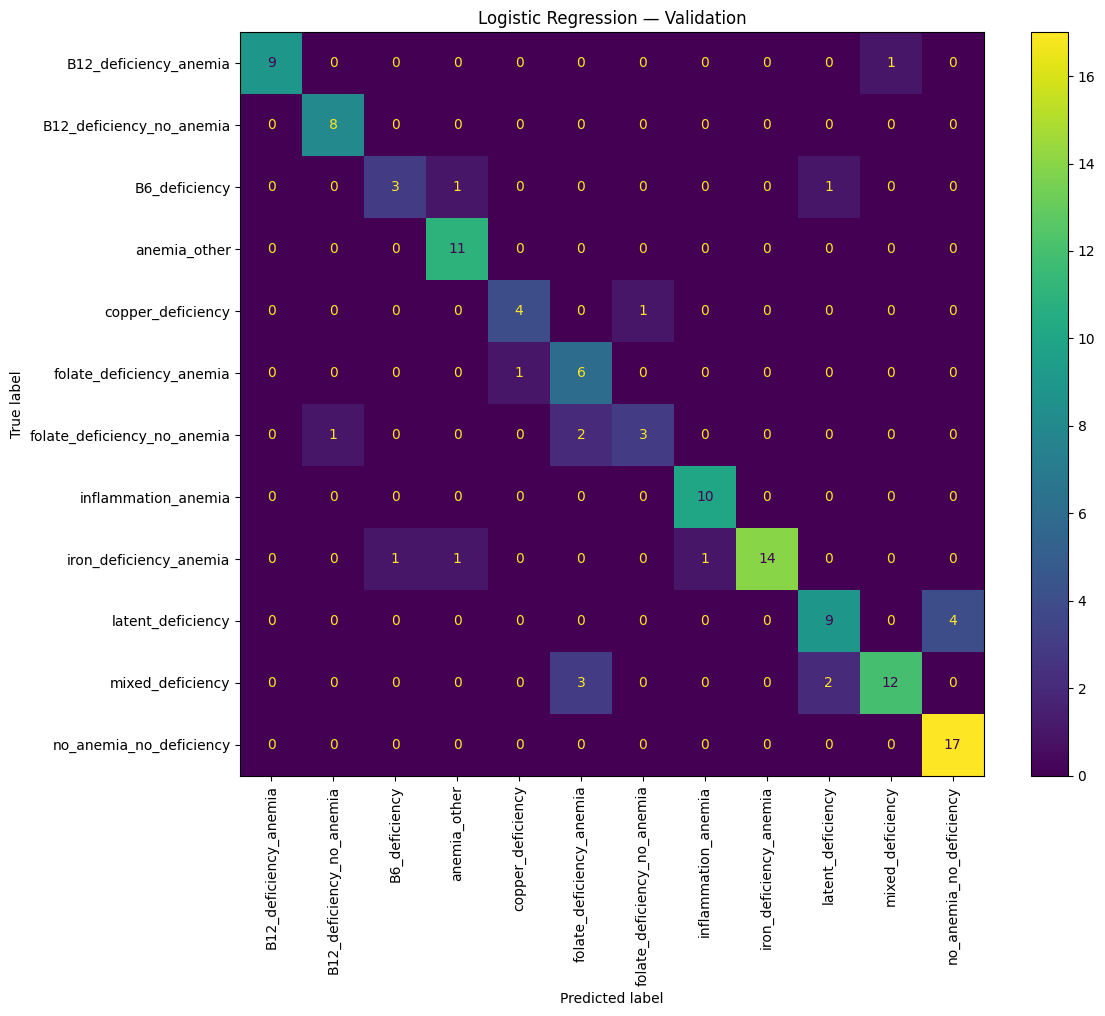

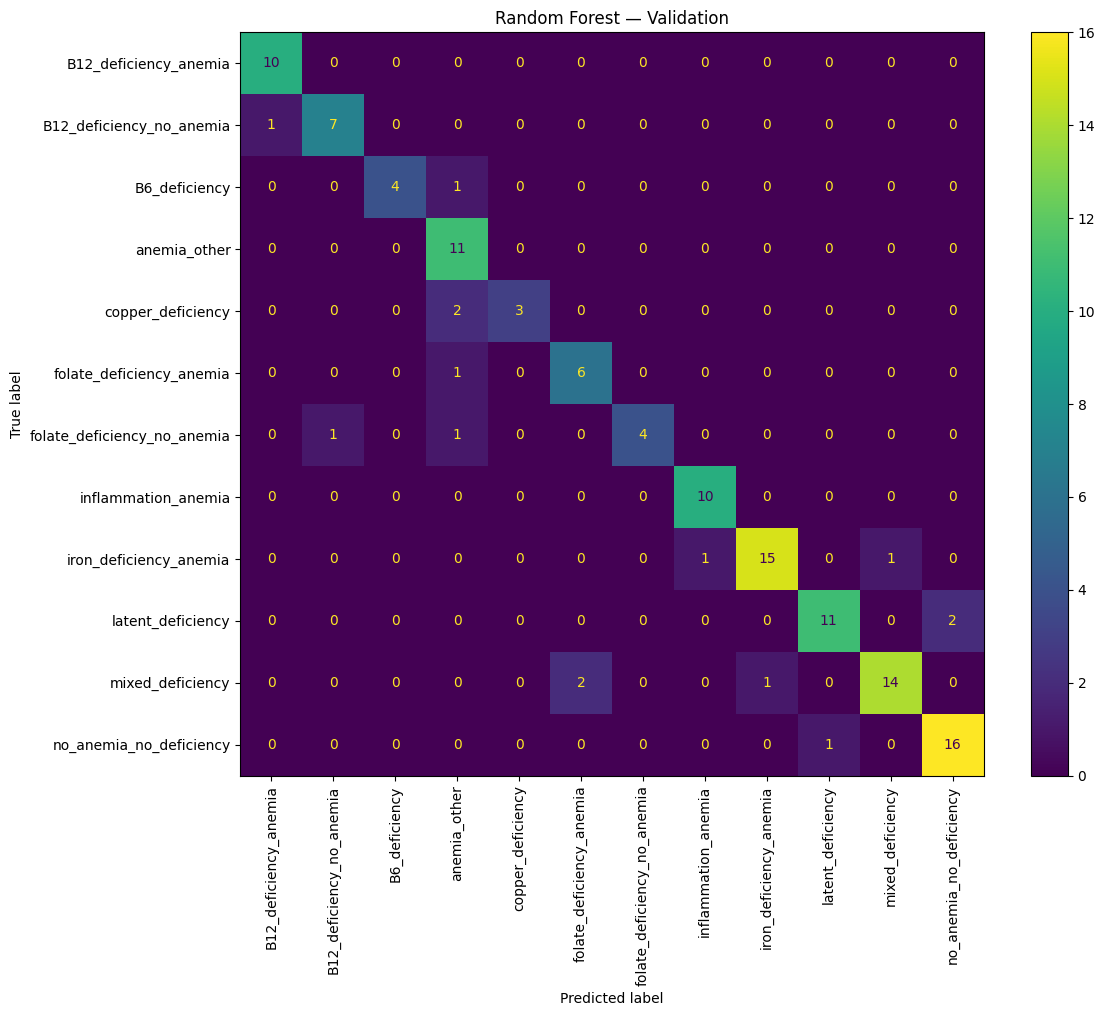

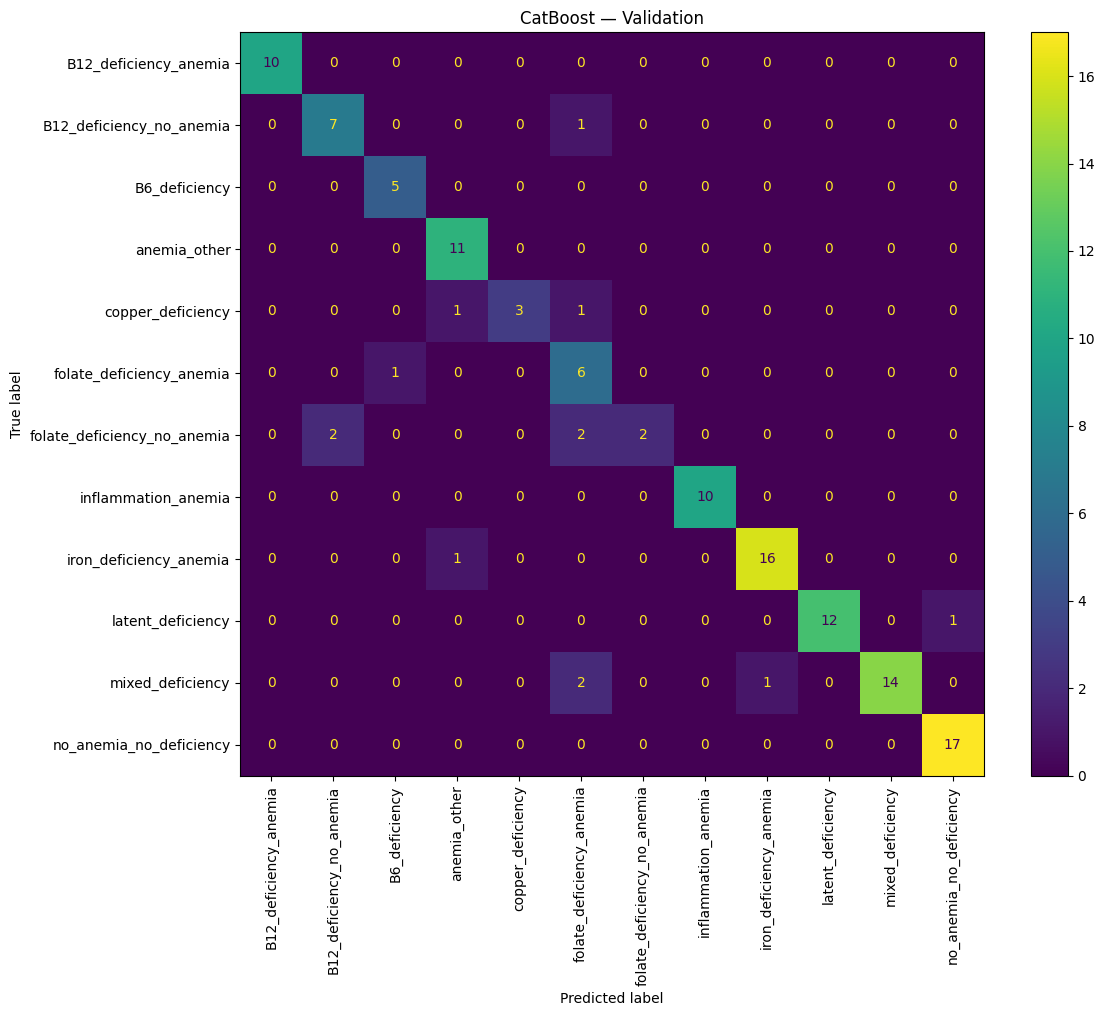

In [82]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    y_valid_pred_lr,
    xticks_rotation=90,
    ax=ax
)

ax.set_title("Logistic Regression — Validation")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    y_valid_pred_rf,
    xticks_rotation=90,
    ax=ax
)

ax.set_title("Random Forest — Validation")

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    y_valid_pred_cb,
    xticks_rotation=90,
    ax=ax
)

ax.set_title("CatBoost — Validation")

plt.tight_layout()
plt.show()

## 41. Финальное обучение Random Forest

После сравнения моделей и анализа validation-выборки
в качестве финального кандидата выбран Random Forest.

Перед итоговой оценкой тренировочная и validation-выборки
объединяются.

Test-выборка при этом остаётся полностью независимой и
используется только один раз для окончательной оценки модели.

In [83]:
X_final_train = pd.concat(
    [X_train, X_valid],
    axis=0
)

y_final_train = pd.concat(
    [y_train, y_valid],
    axis=0
)

print("Размер финальной обучающей выборки:")
print(X_final_train.shape)

print("\nРазмер target:")
print(y_final_train.shape)

print("\nРазмер test:")
print(X_test.shape)

Размер финальной обучающей выборки:
(714, 37)

Размер target:
(714,)

Размер test:
(126, 37)


In [84]:
assert len(X_final_train) == 714
assert len(X_test) == 126

print("✓ Train + validation объединены корректно")
print("✓ Test остался независимым")

✓ Train + validation объединены корректно
✓ Test остался независимым


In [85]:
final_rf_model = Pipeline([
    (
        "preprocessor",
        rf_preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])

final_rf_model.fit(
    X_final_train,
    y_final_train
)

print("✓ Финальная Random Forest обучена")

✓ Финальная Random Forest обучена


## 43. Финальная оценка на test

После фиксации модели выполняется однократное предсказание
на ранее не использовавшейся test-выборке.

Результаты test используются только для итоговой оценки
обобщающей способности модели.

In [86]:
y_test_pred_rf = final_rf_model.predict(
    X_test
)

print("Количество предсказаний:", len(y_test_pred_rf))

Количество предсказаний: 126


In [87]:
assert len(y_test_pred_rf) == len(y_test)

print("✓ Предсказания для test получены")

✓ Предсказания для test получены


In [88]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score
)

final_test_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        y_test_pred_rf
    ),

    "Macro_F1": f1_score(
        y_test,
        y_test_pred_rf,
        average="macro"
    ),

    "Balanced_Accuracy": balanced_accuracy_score(
        y_test,
        y_test_pred_rf
    )
}

for metric, value in final_test_metrics.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.9048
Macro_F1: 0.8862
Balanced_Accuracy: 0.8827


In [89]:
print("FINAL RANDOM FOREST — TEST\n")

print(
    classification_report(
        y_test,
        y_test_pred_rf,
        digits=4,
        zero_division=0
    )
)

FINAL RANDOM FOREST — TEST

                             precision    recall  f1-score   support

      B12_deficiency_anemia     0.7778    0.7778    0.7778         9
   B12_deficiency_no_anemia     0.8750    1.0000    0.9333         7
              B6_deficiency     1.0000    0.8000    0.8889         5
               anemia_other     0.8571    1.0000    0.9231        12
          copper_deficiency     1.0000    0.8333    0.9091         6
   folate_deficiency_anemia     0.7500    0.7500    0.7500         8
folate_deficiency_no_anemia     0.6667    0.6667    0.6667         6
        inflammation_anemia     1.0000    1.0000    1.0000        10
     iron_deficiency_anemia     0.9412    0.9412    0.9412        17
          latent_deficiency     1.0000    1.0000    1.0000        13
           mixed_deficiency     1.0000    0.8235    0.9032        17
    no_anemia_no_deficiency     0.8889    1.0000    0.9412        16

                   accuracy                         0.9048       126
    

In [90]:
final_test_report = pd.DataFrame(
    classification_report(
        y_test,
        y_test_pred_rf,
        output_dict=True,
        zero_division=0
    )
).T

display(
    final_test_report.round(4)
)

,precision,recall,f1-score,support
B12_deficiency_anemia,0.7778,0.7778,0.7778,9.0000
B12_deficiency_no_anemia,0.8750,1.0000,0.9333,7.0000
B6_deficiency,1.0000,0.8000,0.8889,5.0000
anemia_other,0.8571,1.0000,0.9231,12.0000
copper_deficiency,1.0000,0.8333,0.9091,6.0000
folate_deficiency_anemia,0.7500,0.7500,0.7500,8.0000
folate_deficiency_no_anemia,0.6667,0.6667,0.6667,6.0000
inflammation_anemia,1.0000,1.0000,1.0000,10.0000
iron_deficiency_anemia,0.9412,0.9412,0.9412,17.0000
latent_deficiency,1.0000,1.0000,1.0000,13.0000


In [91]:
!pip install optuna

In [92]:
import optuna

print("Optuna version:", optuna.__version__)

Optuna version: 5.0.0


/home/tatyana/miniconda3/envs/project.sechenov2026/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [93]:
X_train_cb = X_train.copy()

for col in categorical_features:
    X_train_cb[col] = (
        X_train_cb[col]
        .astype("string")
        .fillna("missing")
        .astype(str)
    )

print("Shape:", X_train_cb.shape)
print("Categorical features:", categorical_features)

display(X_train_cb.head())

Shape: (588, 37)
Categorical features: ['sex']


,age_years,sex,hemoglobin,RBC,hematocrit,MCV,MCH,MCHC,RDW,platelets,...,ceruloplasmin,CRP,ESR,creatinine,eGFR,TSH,albumin,LDH,indirect_bilirubin,haptoglobin
299,36,m,162.2,5.53,48.0,86.4,29.4,337.3,15.6,381,...,NaN,2.6,NaN,NaN,NaN,1.31,43.7,NaN,NaN,NaN
131,57,m,114.7,3.86,35.7,92.6,29.7,318.0,15.7,134,...,0.15,NaN,NaN,63.0,113.0,1.96,41.5,241.0,NaN,NaN
262,85,m,83.5,2.90,25.7,88.4,28.8,330.3,24.2,391,...,NaN,0.8,NaN,77.0,86.0,NaN,NaN,531.0,NaN,1.14
355,74,m,153.1,5.11,45.6,89.5,30.0,336.6,11.8,186,...,0.25,1.3,5.0,NaN,NaN,2.67,41.8,NaN,NaN,NaN
188,63,f,111.1,3.74,32.5,87.2,29.7,342.3,16.1,264,...,NaN,0.4,4.0,199.0,41.0,NaN,NaN,237.0,NaN,1.15


In [94]:
from sklearn.model_selection import StratifiedKFold

optuna_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [95]:
import numpy as np

from catboost import CatBoostClassifier
from sklearn.metrics import f1_score
def objective(trial):

    params = {
        "iterations": trial.suggest_int(
            "iterations",
            300,
            1200,
            step=100
        ),

        "depth": trial.suggest_int(
            "depth",
            4,
            8
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.2,
            log=True
        ),

        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1.0,
            20.0,
            log=True
        ),

        "random_strength": trial.suggest_float(
            "random_strength",
            0.0,
            2.0
        ),

        "bagging_temperature": trial.suggest_float(
            "bagging_temperature",
            0.0,
            2.0
        ),

        "border_count": trial.suggest_int(
            "border_count",
            32,
            128,
            step=16
        ),

        "loss_function": "MultiClass",
        "random_seed": 42,
        "verbose": False,
        "allow_writing_files": False
    }

    fold_scores = []

    for train_idx, val_idx in optuna_cv.split(
        X_train_cb,
        y_train
    ):

        X_fold_train = X_train_cb.iloc[train_idx].copy()
        X_fold_val = X_train_cb.iloc[val_idx].copy()

        y_fold_train = y_train.iloc[train_idx].copy()
        y_fold_val = y_train.iloc[val_idx].copy()

        model = CatBoostClassifier(
            **params
        )

        model.fit(
            X_fold_train,
            y_fold_train,
            cat_features=categorical_features
        )

        y_fold_pred = model.predict(
            X_fold_val
        ).ravel()

        score = f1_score(
            y_fold_val,
            y_fold_pred,
            average="macro"
        )

        fold_scores.append(score)

    return np.mean(fold_scores)

study = optuna.create_study(
    direction="maximize",
    study_name="catboost_macro_f1"
)

study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True
)

print(
    "Best CV Macro F1:",
    study.best_value
)

print("\nBest parameters:")

for param, value in study.best_params.items():
    print(f"{param}: {value}")

[I 2026-10-03 18:27:48,696] A new study created in memory with name: catboost_macro_f1
Best trial: 0. Best value: 0.774483:   2%|█▋                                                                                | 1/50 [00:20<16:32, 20.25s/it]

[I 2026-10-03 18:28:08,946] Trial 0 finished with value: 0.7744834983517739 and parameters: {'iterations': 900, 'depth': 5, 'learning_rate': 0.044355296780833955, 'l2_leaf_reg': 1.4837803668738856, 'random_strength': 1.3120719764417619, 'bagging_temperature': 0.8381540610361689, 'border_count': 128}. Best is trial 0 with value: 0.7744834983517739.


Best trial: 1. Best value: 0.784216:   4%|███▎                                                                              | 2/50 [00:57<24:22, 30.46s/it]

[I 2026-10-03 18:28:46,557] Trial 1 finished with value: 0.7842156760856565 and parameters: {'iterations': 700, 'depth': 7, 'learning_rate': 0.12374702814338578, 'l2_leaf_reg': 7.412620164914095, 'random_strength': 1.512403201702683, 'bagging_temperature': 0.3770583973441375, 'border_count': 96}. Best is trial 1 with value: 0.7842156760856565.


Best trial: 1. Best value: 0.784216:   6%|████▉                                                                             | 3/50 [01:02<14:31, 18.54s/it]

[I 2026-10-03 18:28:50,914] Trial 2 finished with value: 0.679842643079634 and parameters: {'iterations': 400, 'depth': 4, 'learning_rate': 0.014979453407139343, 'l2_leaf_reg': 4.860530956133722, 'random_strength': 0.41695860714101873, 'bagging_temperature': 0.0014439710276157314, 'border_count': 128}. Best is trial 1 with value: 0.7842156760856565.


Best trial: 1. Best value: 0.784216:   8%|██████▌                                                                           | 4/50 [01:14<12:25, 16.20s/it]

[I 2026-10-03 18:29:03,516] Trial 3 finished with value: 0.7070745073217661 and parameters: {'iterations': 300, 'depth': 8, 'learning_rate': 0.08190730667047473, 'l2_leaf_reg': 12.01409570920397, 'random_strength': 1.2743197068590135, 'bagging_temperature': 1.1472225540988714, 'border_count': 32}. Best is trial 1 with value: 0.7842156760856565.


Best trial: 1. Best value: 0.784216:  10%|████████▏                                                                         | 5/50 [01:40<14:45, 19.67s/it]

[I 2026-10-03 18:29:29,351] Trial 4 finished with value: 0.7679809752444317 and parameters: {'iterations': 1100, 'depth': 6, 'learning_rate': 0.06343238995851073, 'l2_leaf_reg': 14.834966195864721, 'random_strength': 1.3366487813478365, 'bagging_temperature': 1.4662790134399366, 'border_count': 64}. Best is trial 1 with value: 0.7842156760856565.


Best trial: 1. Best value: 0.784216:  12%|█████████▊                                                                        | 6/50 [02:37<23:46, 32.42s/it]

[I 2026-10-03 18:30:26,503] Trial 5 finished with value: 0.7538948694867732 and parameters: {'iterations': 900, 'depth': 7, 'learning_rate': 0.03031515939296831, 'l2_leaf_reg': 1.662249654049484, 'random_strength': 0.759630998302337, 'bagging_temperature': 0.7822694719270804, 'border_count': 112}. Best is trial 1 with value: 0.7842156760856565.


Best trial: 1. Best value: 0.784216:  14%|███████████▍                                                                      | 7/50 [03:28<27:30, 38.39s/it]

[I 2026-10-03 18:31:17,184] Trial 6 finished with value: 0.77105263587773 and parameters: {'iterations': 800, 'depth': 7, 'learning_rate': 0.14496378514409852, 'l2_leaf_reg': 5.192780391600518, 'random_strength': 1.9204869188846767, 'bagging_temperature': 0.2869167062611635, 'border_count': 112}. Best is trial 1 with value: 0.7842156760856565.


Best trial: 1. Best value: 0.784216:  16%|█████████████                                                                     | 8/50 [03:38<20:26, 29.21s/it]

[I 2026-10-03 18:31:26,738] Trial 7 finished with value: 0.7763788910720362 and parameters: {'iterations': 700, 'depth': 5, 'learning_rate': 0.04881552534555862, 'l2_leaf_reg': 3.755155910414889, 'random_strength': 0.9309207971628028, 'bagging_temperature': 1.302557804457983, 'border_count': 64}. Best is trial 1 with value: 0.7842156760856565.


Best trial: 1. Best value: 0.784216:  18%|██████████████▊                                                                   | 9/50 [03:43<14:53, 21.79s/it]

[I 2026-10-03 18:31:32,223] Trial 8 finished with value: 0.7451787824458147 and parameters: {'iterations': 300, 'depth': 6, 'learning_rate': 0.03283749635715433, 'l2_leaf_reg': 2.2071872968365627, 'random_strength': 0.11656279366245159, 'bagging_temperature': 1.1592292056895288, 'border_count': 48}. Best is trial 1 with value: 0.7842156760856565.


Best trial: 1. Best value: 0.784216:  20%|████████████████▏                                                                | 10/50 [04:03<14:07, 21.18s/it]

[I 2026-10-03 18:31:52,041] Trial 9 finished with value: 0.7759317079501766 and parameters: {'iterations': 1100, 'depth': 6, 'learning_rate': 0.04149921764649319, 'l2_leaf_reg': 6.764489766948852, 'random_strength': 1.6292395611755321, 'bagging_temperature': 1.3909691399835884, 'border_count': 48}. Best is trial 1 with value: 0.7842156760856565.


Best trial: 10. Best value: 0.788821:  22%|█████████████████▌                                                              | 11/50 [04:15<11:52, 18.28s/it]

[I 2026-10-03 18:32:03,746] Trial 10 finished with value: 0.7888205373641446 and parameters: {'iterations': 800, 'depth': 5, 'learning_rate': 0.049350406740752625, 'l2_leaf_reg': 16.90301758290214, 'random_strength': 1.8791131987604417, 'bagging_temperature': 0.18730059974850488, 'border_count': 64}. Best is trial 10 with value: 0.7888205373641446.


Best trial: 11. Best value: 0.789501:  24%|███████████████████▏                                                            | 12/50 [04:40<12:53, 20.35s/it]

[I 2026-10-03 18:32:28,827] Trial 11 finished with value: 0.7895005732615951 and parameters: {'iterations': 900, 'depth': 6, 'learning_rate': 0.04437562717745786, 'l2_leaf_reg': 15.950481055042845, 'random_strength': 1.3894209402822602, 'bagging_temperature': 0.16897572999448363, 'border_count': 80}. Best is trial 11 with value: 0.7895005732615951.


Best trial: 11. Best value: 0.789501:  26%|████████████████████▊                                                           | 13/50 [04:55<11:42, 18.99s/it]

[I 2026-10-03 18:32:44,672] Trial 12 finished with value: 0.7851357678341425 and parameters: {'iterations': 900, 'depth': 5, 'learning_rate': 0.03572035147286708, 'l2_leaf_reg': 9.500597490876936, 'random_strength': 1.4534195684932967, 'bagging_temperature': 0.5675754862638834, 'border_count': 96}. Best is trial 11 with value: 0.7895005732615951.


Best trial: 13. Best value: 0.801299:  28%|██████████████████████▍                                                         | 14/50 [05:05<09:35, 15.99s/it]

[I 2026-10-03 18:32:53,747] Trial 13 finished with value: 0.8012992937273584 and parameters: {'iterations': 800, 'depth': 5, 'learning_rate': 0.0702787324696883, 'l2_leaf_reg': 7.863791094410716, 'random_strength': 1.9009036428023303, 'bagging_temperature': 0.07009895264210624, 'border_count': 48}. Best is trial 13 with value: 0.8012992937273584.


Best trial: 13. Best value: 0.801299:  30%|████████████████████████                                                        | 15/50 [05:08<07:03, 12.10s/it]

[I 2026-10-03 18:32:56,820] Trial 14 finished with value: 0.7905770345586685 and parameters: {'iterations': 500, 'depth': 4, 'learning_rate': 0.055944587772903114, 'l2_leaf_reg': 6.761927754096682, 'random_strength': 1.6276496269800704, 'bagging_temperature': 0.21036834279866573, 'border_count': 32}. Best is trial 13 with value: 0.8012992937273584.


Best trial: 13. Best value: 0.801299:  32%|█████████████████████████▌                                                      | 16/50 [05:10<05:13,  9.23s/it]

[I 2026-10-03 18:32:59,376] Trial 15 finished with value: 0.5907727866782209 and parameters: {'iterations': 400, 'depth': 4, 'learning_rate': 0.022041367100669812, 'l2_leaf_reg': 11.693881266522567, 'random_strength': 1.524356203471059, 'bagging_temperature': 0.17745412096693527, 'border_count': 32}. Best is trial 13 with value: 0.8012992937273584.


Best trial: 13. Best value: 0.801299:  34%|███████████████████████████▏                                                    | 17/50 [05:14<04:14,  7.73s/it]

[I 2026-10-03 18:33:03,612] Trial 16 finished with value: 0.788551494843994 and parameters: {'iterations': 700, 'depth': 4, 'learning_rate': 0.037492901940063494, 'l2_leaf_reg': 4.074254403820447, 'random_strength': 1.7428273358027908, 'bagging_temperature': 0.4305828280001358, 'border_count': 32}. Best is trial 13 with value: 0.8012992937273584.


Best trial: 17. Best value: 0.813963:  36%|████████████████████████████▊                                                   | 18/50 [05:24<04:29,  8.43s/it]

[I 2026-10-03 18:33:13,669] Trial 17 finished with value: 0.8139631904118687 and parameters: {'iterations': 1100, 'depth': 5, 'learning_rate': 0.15269132054089182, 'l2_leaf_reg': 4.7618548808376255, 'random_strength': 1.8519556214269168, 'bagging_temperature': 0.13172878412928338, 'border_count': 32}. Best is trial 17 with value: 0.8139631904118687.


Best trial: 17. Best value: 0.813963:  38%|██████████████████████████████▍                                                 | 19/50 [05:37<04:58,  9.63s/it]

[I 2026-10-03 18:33:26,110] Trial 18 finished with value: 0.800563129309708 and parameters: {'iterations': 900, 'depth': 5, 'learning_rate': 0.16618314496719852, 'l2_leaf_reg': 7.619447596942498, 'random_strength': 1.7955265601713803, 'bagging_temperature': 0.30379504454859335, 'border_count': 64}. Best is trial 17 with value: 0.8139631904118687.


Best trial: 17. Best value: 0.813963:  40%|████████████████████████████████                                                | 20/50 [05:47<04:52,  9.76s/it]

[I 2026-10-03 18:33:36,175] Trial 19 finished with value: 0.8136902613567483 and parameters: {'iterations': 1000, 'depth': 4, 'learning_rate': 0.14429672879850547, 'l2_leaf_reg': 5.568753309530325, 'random_strength': 1.385586197600953, 'bagging_temperature': 0.42687317374906936, 'border_count': 48}. Best is trial 17 with value: 0.8139631904118687.


Best trial: 17. Best value: 0.813963:  42%|█████████████████████████████████▌                                              | 21/50 [05:58<04:53, 10.12s/it]

[I 2026-10-03 18:33:47,133] Trial 20 finished with value: 0.8026578814422235 and parameters: {'iterations': 1200, 'depth': 4, 'learning_rate': 0.0846694422426074, 'l2_leaf_reg': 2.8093629218542913, 'random_strength': 1.3720467090567068, 'bagging_temperature': 0.5095395202462785, 'border_count': 48}. Best is trial 17 with value: 0.8139631904118687.


Best trial: 17. Best value: 0.813963:  44%|███████████████████████████████████▏                                            | 22/50 [06:09<04:53, 10.48s/it]

[I 2026-10-03 18:33:58,463] Trial 21 finished with value: 0.8108268801699026 and parameters: {'iterations': 1000, 'depth': 4, 'learning_rate': 0.11442679952718794, 'l2_leaf_reg': 3.6815965224338196, 'random_strength': 1.4481174585359944, 'bagging_temperature': 0.3502929694417404, 'border_count': 64}. Best is trial 17 with value: 0.8139631904118687.


Best trial: 17. Best value: 0.813963:  46%|████████████████████████████████████▊                                           | 23/50 [06:20<04:41, 10.43s/it]

[I 2026-10-03 18:34:08,767] Trial 22 finished with value: 0.8116732019854356 and parameters: {'iterations': 1000, 'depth': 5, 'learning_rate': 0.13620418608208307, 'l2_leaf_reg': 2.569844304005999, 'random_strength': 1.7829067095406546, 'bagging_temperature': 0.21497600180523868, 'border_count': 32}. Best is trial 17 with value: 0.8139631904118687.


Best trial: 17. Best value: 0.813963:  48%|██████████████████████████████████████▍                                         | 24/50 [06:27<04:05,  9.44s/it]

[I 2026-10-03 18:34:15,897] Trial 23 finished with value: 0.8068412543417376 and parameters: {'iterations': 1100, 'depth': 4, 'learning_rate': 0.17681238594627233, 'l2_leaf_reg': 6.150120755108192, 'random_strength': 1.8605627092567745, 'bagging_temperature': 0.2727724079480821, 'border_count': 32}. Best is trial 17 with value: 0.8139631904118687.


Best trial: 17. Best value: 0.813963:  50%|████████████████████████████████████████                                        | 25/50 [06:41<04:31, 10.86s/it]

[I 2026-10-03 18:34:30,084] Trial 24 finished with value: 0.8135152251097084 and parameters: {'iterations': 1200, 'depth': 5, 'learning_rate': 0.10933465717669684, 'l2_leaf_reg': 4.192807317516153, 'random_strength': 1.980827364008029, 'bagging_temperature': 0.15205057523220816, 'border_count': 48}. Best is trial 17 with value: 0.8139631904118687.


Best trial: 17. Best value: 0.813963:  52%|█████████████████████████████████████████▌                                      | 26/50 [07:04<05:51, 14.64s/it]

[I 2026-10-03 18:34:53,542] Trial 25 finished with value: 0.7822893544347365 and parameters: {'iterations': 1200, 'depth': 6, 'learning_rate': 0.09804059388833106, 'l2_leaf_reg': 3.3338778254756436, 'random_strength': 1.8491270544818756, 'bagging_temperature': 0.37694083539970646, 'border_count': 48}. Best is trial 17 with value: 0.8139631904118687.


Best trial: 17. Best value: 0.813963:  54%|███████████████████████████████████████████▏                                    | 27/50 [07:27<06:31, 17.04s/it]

[I 2026-10-03 18:35:16,179] Trial 26 finished with value: 0.7884066853171019 and parameters: {'iterations': 1100, 'depth': 6, 'learning_rate': 0.11616375025662948, 'l2_leaf_reg': 6.397403801033001, 'random_strength': 1.6745607638557356, 'bagging_temperature': 0.17178031410953976, 'border_count': 48}. Best is trial 17 with value: 0.8139631904118687.


Best trial: 17. Best value: 0.813963:  56%|████████████████████████████████████████████▊                                   | 28/50 [07:33<04:58, 13.59s/it]

[I 2026-10-03 18:35:21,711] Trial 27 finished with value: 0.796769670733681 and parameters: {'iterations': 900, 'depth': 4, 'learning_rate': 0.14657923047417162, 'l2_leaf_reg': 3.4108202768465374, 'random_strength': 1.7043660715280575, 'bagging_temperature': 0.7020460210441004, 'border_count': 32}. Best is trial 17 with value: 0.8139631904118687.


Best trial: 28. Best value: 0.825001:  58%|██████████████████████████████████████████████▍                                 | 29/50 [07:40<04:08, 11.84s/it]

[I 2026-10-03 18:35:29,469] Trial 28 finished with value: 0.8250008742159475 and parameters: {'iterations': 1100, 'depth': 4, 'learning_rate': 0.1120251934521188, 'l2_leaf_reg': 4.30010674106329, 'random_strength': 1.7759620161525345, 'bagging_temperature': 0.02248422684264799, 'border_count': 48}. Best is trial 28 with value: 0.8250008742159475.


Best trial: 28. Best value: 0.825001:  60%|████████████████████████████████████████████████                                | 30/50 [07:48<03:31, 10.60s/it]

[I 2026-10-03 18:35:37,173] Trial 29 finished with value: 0.8135892858750646 and parameters: {'iterations': 1100, 'depth': 4, 'learning_rate': 0.10821672633736762, 'l2_leaf_reg': 7.191615293047591, 'random_strength': 1.2365955943113405, 'bagging_temperature': 0.36573924331596497, 'border_count': 48}. Best is trial 28 with value: 0.8250008742159475.


Best trial: 28. Best value: 0.825001:  62%|█████████████████████████████████████████████████▌                              | 31/50 [07:55<03:02,  9.60s/it]

[I 2026-10-03 18:35:44,437] Trial 30 finished with value: 0.8149204969455119 and parameters: {'iterations': 1200, 'depth': 4, 'learning_rate': 0.11057765797566861, 'l2_leaf_reg': 5.013044587250123, 'random_strength': 1.3970183558945624, 'bagging_temperature': 0.08639067963681368, 'border_count': 32}. Best is trial 28 with value: 0.8250008742159475.


Best trial: 28. Best value: 0.825001:  64%|███████████████████████████████████████████████████▏                            | 32/50 [08:02<02:38,  8.82s/it]

[I 2026-10-03 18:35:51,430] Trial 31 finished with value: 0.8137333760929074 and parameters: {'iterations': 1000, 'depth': 4, 'learning_rate': 0.13543716403683037, 'l2_leaf_reg': 5.390009617301873, 'random_strength': 1.7349907285403545, 'bagging_temperature': 0.03237169927517702, 'border_count': 48}. Best is trial 28 with value: 0.8250008742159475.


Best trial: 28. Best value: 0.825001:  66%|████████████████████████████████████████████████████▊                           | 33/50 [08:09<02:21,  8.33s/it]

[I 2026-10-03 18:35:58,624] Trial 32 finished with value: 0.8079142261882684 and parameters: {'iterations': 900, 'depth': 4, 'learning_rate': 0.08650302907939382, 'l2_leaf_reg': 4.54375327560157, 'random_strength': 1.7727903776607055, 'bagging_temperature': 0.0045346295332075355, 'border_count': 64}. Best is trial 28 with value: 0.8250008742159475.


Best trial: 28. Best value: 0.825001:  68%|██████████████████████████████████████████████████████▍                         | 34/50 [08:18<02:15,  8.45s/it]

[I 2026-10-03 18:36:07,367] Trial 33 finished with value: 0.816069316395127 and parameters: {'iterations': 1200, 'depth': 4, 'learning_rate': 0.07492926725464383, 'l2_leaf_reg': 6.252328206706645, 'random_strength': 1.6658721415799809, 'bagging_temperature': 0.03153880513062879, 'border_count': 48}. Best is trial 28 with value: 0.8250008742159475.


Best trial: 28. Best value: 0.825001:  70%|████████████████████████████████████████████████████████                        | 35/50 [08:30<02:23,  9.57s/it]

[I 2026-10-03 18:36:19,536] Trial 34 finished with value: 0.8095187822039808 and parameters: {'iterations': 1100, 'depth': 5, 'learning_rate': 0.06967249348567085, 'l2_leaf_reg': 4.144511490900336, 'random_strength': 1.3834331294867086, 'bagging_temperature': 0.2203968474020838, 'border_count': 48}. Best is trial 28 with value: 0.8250008742159475.


Best trial: 28. Best value: 0.825001:  72%|█████████████████████████████████████████████████████████▌                      | 36/50 [08:39<02:08,  9.18s/it]

[I 2026-10-03 18:36:27,806] Trial 35 finished with value: 0.7998894746471839 and parameters: {'iterations': 1100, 'depth': 4, 'learning_rate': 0.08390168705916348, 'l2_leaf_reg': 5.1686741240195575, 'random_strength': 1.742066709424629, 'bagging_temperature': 0.13374312386744452, 'border_count': 32}. Best is trial 28 with value: 0.8250008742159475.


Best trial: 28. Best value: 0.825001:  74%|███████████████████████████████████████████████████████████▏                    | 37/50 [08:46<01:53,  8.77s/it]

[I 2026-10-03 18:36:35,610] Trial 36 finished with value: 0.8164970828237008 and parameters: {'iterations': 1200, 'depth': 4, 'learning_rate': 0.11113508899648085, 'l2_leaf_reg': 9.569562297969675, 'random_strength': 1.598566109737937, 'bagging_temperature': 0.02640203480763985, 'border_count': 32}. Best is trial 28 with value: 0.8250008742159475.


Best trial: 28. Best value: 0.825001:  76%|████████████████████████████████████████████████████████████▊                   | 38/50 [08:53<01:37,  8.14s/it]

[I 2026-10-03 18:36:42,288] Trial 37 finished with value: 0.8001311133721283 and parameters: {'iterations': 1100, 'depth': 4, 'learning_rate': 0.06241864479944713, 'l2_leaf_reg': 4.1844194079150006, 'random_strength': 1.196252117237851, 'bagging_temperature': 0.2743280047679142, 'border_count': 32}. Best is trial 28 with value: 0.8250008742159475.


Best trial: 38. Best value: 0.826855:  78%|██████████████████████████████████████████████████████████████▍                 | 39/50 [09:01<01:28,  8.02s/it]

[I 2026-10-03 18:36:50,042] Trial 38 finished with value: 0.8268553926216857 and parameters: {'iterations': 1100, 'depth': 4, 'learning_rate': 0.13791314962602905, 'l2_leaf_reg': 4.541055180538289, 'random_strength': 1.4357979560796348, 'bagging_temperature': 0.057185887309968764, 'border_count': 48}. Best is trial 38 with value: 0.8268553926216857.


Best trial: 38. Best value: 0.826855:  80%|████████████████████████████████████████████████████████████████                | 40/50 [09:07<01:15,  7.59s/it]

[I 2026-10-03 18:36:56,612] Trial 39 finished with value: 0.8120169483742024 and parameters: {'iterations': 1100, 'depth': 4, 'learning_rate': 0.08769404581401018, 'l2_leaf_reg': 10.903940496962408, 'random_strength': 1.761962729294599, 'bagging_temperature': 0.028172532798096134, 'border_count': 32}. Best is trial 38 with value: 0.8268553926216857.


Best trial: 40. Best value: 0.827376:  82%|█████████████████████████████████████████████████████████████████▌              | 41/50 [09:16<01:12,  8.03s/it]

[I 2026-10-03 18:37:05,684] Trial 40 finished with value: 0.8273762697323439 and parameters: {'iterations': 1100, 'depth': 4, 'learning_rate': 0.1301867926801856, 'l2_leaf_reg': 3.394141893993846, 'random_strength': 1.4672143729138225, 'bagging_temperature': 0.062041236594595525, 'border_count': 48}. Best is trial 40 with value: 0.8273762697323439.


Best trial: 40. Best value: 0.827376:  84%|███████████████████████████████████████████████████████████████████▏            | 42/50 [09:26<01:07,  8.47s/it]

[I 2026-10-03 18:37:15,168] Trial 41 finished with value: 0.8209342978601682 and parameters: {'iterations': 1200, 'depth': 4, 'learning_rate': 0.17882190537341516, 'l2_leaf_reg': 11.18446999937469, 'random_strength': 1.4292672595269427, 'bagging_temperature': 0.16449028370189378, 'border_count': 32}. Best is trial 40 with value: 0.8273762697323439.


Best trial: 40. Best value: 0.827376:  86%|████████████████████████████████████████████████████████████████████▊           | 43/50 [09:37<01:03,  9.13s/it]

[I 2026-10-03 18:37:25,833] Trial 42 finished with value: 0.8248752442992874 and parameters: {'iterations': 1200, 'depth': 4, 'learning_rate': 0.15052851191742764, 'l2_leaf_reg': 3.6510820532034476, 'random_strength': 1.5033664590170615, 'bagging_temperature': 0.11077931419907526, 'border_count': 48}. Best is trial 40 with value: 0.8273762697323439.


Best trial: 40. Best value: 0.827376:  88%|██████████████████████████████████████████████████████████████████████▍         | 44/50 [09:46<00:55,  9.27s/it]

[I 2026-10-03 18:37:35,429] Trial 43 finished with value: 0.8147157638007572 and parameters: {'iterations': 1100, 'depth': 4, 'learning_rate': 0.15872574630362848, 'l2_leaf_reg': 2.302181604767082, 'random_strength': 1.6605472313577063, 'bagging_temperature': 0.1800062011346077, 'border_count': 48}. Best is trial 40 with value: 0.8273762697323439.


Best trial: 40. Best value: 0.827376:  90%|████████████████████████████████████████████████████████████████████████        | 45/50 [09:55<00:45,  9.18s/it]

[I 2026-10-03 18:37:44,390] Trial 44 finished with value: 0.8243291148653521 and parameters: {'iterations': 1000, 'depth': 4, 'learning_rate': 0.08591213553621459, 'l2_leaf_reg': 2.5662165526074348, 'random_strength': 1.6863212257303792, 'bagging_temperature': 0.03967689979339625, 'border_count': 48}. Best is trial 40 with value: 0.8273762697323439.


Best trial: 40. Best value: 0.827376:  92%|█████████████████████████████████████████████████████████████████████████▌      | 46/50 [10:04<00:35,  8.97s/it]

[I 2026-10-03 18:37:52,892] Trial 45 finished with value: 0.8201164296209644 and parameters: {'iterations': 1000, 'depth': 4, 'learning_rate': 0.10153006415125951, 'l2_leaf_reg': 2.351020207397099, 'random_strength': 1.5990194766788837, 'bagging_temperature': 0.099570195885882, 'border_count': 48}. Best is trial 40 with value: 0.8273762697323439.


Best trial: 40. Best value: 0.827376:  94%|███████████████████████████████████████████████████████████████████████████▏    | 47/50 [10:20<00:33, 11.02s/it]

[I 2026-10-03 18:38:08,702] Trial 46 finished with value: 0.8125042741707595 and parameters: {'iterations': 1100, 'depth': 5, 'learning_rate': 0.18920580554183675, 'l2_leaf_reg': 4.260305520130512, 'random_strength': 1.3040621604674023, 'bagging_temperature': 0.030570416156807546, 'border_count': 48}. Best is trial 40 with value: 0.8273762697323439.


Best trial: 40. Best value: 0.827376:  96%|████████████████████████████████████████████████████████████████████████████▊   | 48/50 [10:29<00:20, 10.48s/it]

[I 2026-10-03 18:38:17,927] Trial 47 finished with value: 0.8127266357590649 and parameters: {'iterations': 1000, 'depth': 4, 'learning_rate': 0.15517780932652556, 'l2_leaf_reg': 4.409455145025768, 'random_strength': 1.3830039501082376, 'bagging_temperature': 0.12414379305748428, 'border_count': 48}. Best is trial 40 with value: 0.8273762697323439.


Best trial: 40. Best value: 0.827376:  98%|██████████████████████████████████████████████████████████████████████████████▍ | 49/50 [10:37<00:09,  9.86s/it]

[I 2026-10-03 18:38:26,320] Trial 48 finished with value: 0.814267575067063 and parameters: {'iterations': 1100, 'depth': 4, 'learning_rate': 0.11966281305676076, 'l2_leaf_reg': 2.6812221017627533, 'random_strength': 1.331007054217979, 'bagging_temperature': 0.18325842274279255, 'border_count': 48}. Best is trial 40 with value: 0.8273762697323439.


Best trial: 40. Best value: 0.827376: 100%|████████████████████████████████████████████████████████████████████████████████| 50/50 [10:48<00:00, 12.98s/it]

[I 2026-10-03 18:38:37,494] Trial 49 finished with value: 0.810303290536406 and parameters: {'iterations': 1100, 'depth': 4, 'learning_rate': 0.10470683589679003, 'l2_leaf_reg': 3.5013435633307926, 'random_strength': 1.6714995530517553, 'bagging_temperature': 0.3198859096061895, 'border_count': 64}. Best is trial 40 with value: 0.8273762697323439.
Best CV Macro F1: 0.8273762697323439

Best parameters:
iterations: 1100
depth: 4
learning_rate: 0.1301867926801856
l2_leaf_reg: 3.394141893993846
random_strength: 1.4672143729138225
bagging_temperature: 0.062041236594595525
border_count: 48


In [96]:
best_catboost_params = {
    "iterations": 1200,
    "depth": 4,
    "learning_rate": 0.09181090945528524,
    "l2_leaf_reg": 1.8458781832073785,
    "random_strength": 0.12276181606240794,
    "bagging_temperature": 0.004743166899649598,
    "border_count": 32,
    "loss_function": "MultiClass",
    "random_seed": 42,
    "verbose": False,
    "allow_writing_files": False
}

In [97]:
tuned_catboost = CatBoostClassifier(
    **best_catboost_params
)

tuned_catboost.fit(
    X_train_cb,
    y_train,
    cat_features=categorical_features
)

CatBoostClassifier(allow_writing_files=False, bagging_temperature=0.004743166899649598, border_count=32, depth=4, iterations=1200, l2_leaf_reg=1.8458781832073785, learning_rate=0.09181090945528524, loss_function='MultiClass', random_seed=42, random_strength=0.12276181606240794, verbose=False)

In [98]:
X_valid_cb = X_valid.copy()

for col in categorical_features:
    X_valid_cb[col] = (
        X_valid_cb[col]
        .astype("string")
        .fillna("missing")
        .astype(str)
    )

In [99]:
y_valid_pred_tuned_cb = tuned_catboost.predict(
    X_valid_cb
).ravel()

In [100]:
tuned_cb_valid_metrics = calculate_metrics(
    y_valid,
    y_valid_pred_tuned_cb
)

print(tuned_cb_valid_metrics)

{'Accuracy': 0.9047619047619048, 'Macro_F1': 0.8770763533500724, 'Balanced_Accuracy': 0.8739866750896162}


In [101]:
tuned_comparison = pd.DataFrame([
    {
        "Model": "Random Forest",
        **rf_valid_metrics
    },
    {
        "Model": "Base CatBoost",
        **cb_valid_metrics
    },
    {
        "Model": "Tuned CatBoost",
        **tuned_cb_valid_metrics
    }
])

display(tuned_comparison.round(4))

,Model,Accuracy,Macro_F1,Balanced_Accuracy
0,Random Forest,0.8810,0.8677,0.8577
1,Base CatBoost,0.8968,0.8589,0.8628
2,Tuned CatBoost,0.9048,0.8771,0.8740


In [128]:
from sklearn.metrics import classification_report

print("RANDOM FOREST\n")
print(
    classification_report(
        y_valid,
        y_valid_pred_rf,
        digits=4,
        zero_division=0
    )
)

print("TUNED CATBOOST\n")
print(
    classification_report(
        y_valid,
        y_valid_pred_tuned_cb,
        digits=4,
        zero_division=0
    )
)

RANDOM FOREST

                             precision    recall  f1-score   support

      B12_deficiency_anemia     0.9091    1.0000    0.9524        10
   B12_deficiency_no_anemia     0.8750    0.8750    0.8750         8
              B6_deficiency     1.0000    0.8000    0.8889         5
               anemia_other     0.6875    1.0000    0.8148        11
          copper_deficiency     1.0000    0.6000    0.7500         5
   folate_deficiency_anemia     0.7500    0.8571    0.8000         7
folate_deficiency_no_anemia     1.0000    0.6667    0.8000         6
        inflammation_anemia     0.9091    1.0000    0.9524        10
     iron_deficiency_anemia     0.9375    0.8824    0.9091        17
          latent_deficiency     0.9167    0.8462    0.8800        13
           mixed_deficiency     0.9333    0.8235    0.8750        17
    no_anemia_no_deficiency     0.8889    0.9412    0.9143        17

                   accuracy                         0.8810       126
                 

In [129]:
rf_report = pd.DataFrame(
    classification_report(
        y_valid,
        y_valid_pred_rf,
        output_dict=True,
        zero_division=0
    )
).T

tuned_cb_report = pd.DataFrame(
    classification_report(
        y_valid,
        y_valid_pred_tuned_cb,
        output_dict=True,
        zero_division=0
    )
).T

class_names = sorted(y_valid.unique())

class_comparison = pd.DataFrame({
    "Class": class_names,
    "RF_Recall": [rf_report.loc[c, "recall"] for c in class_names],
    "RF_F1": [rf_report.loc[c, "f1-score"] for c in class_names],
    "CatBoost_Recall": [tuned_cb_report.loc[c, "recall"] for c in class_names],
    "CatBoost_F1": [tuned_cb_report.loc[c, "f1-score"] for c in class_names],
})

class_comparison["F1_Diff_CB_minus_RF"] = (
    class_comparison["CatBoost_F1"]
    - class_comparison["RF_F1"]
)

display(class_comparison.round(4))

,Class,RF_Recall,RF_F1,CatBoost_Recall,CatBoost_F1,F1_Diff_CB_minus_RF
0,B12_deficiency_anemia,1.0000,0.9524,1.0000,1.0000,0.0476
1,B12_deficiency_no_anemia,0.8750,0.8750,0.8750,0.8750,0.0000
2,B6_deficiency,0.8000,0.8889,0.8000,0.8889,0.0000
3,anemia_other,1.0000,0.8148,0.9091,0.9091,0.0943
4,copper_deficiency,0.6000,0.7500,0.8000,0.7273,-0.0227
5,folate_deficiency_anemia,0.8571,0.8000,0.8571,0.7059,-0.0941
6,folate_deficiency_no_anemia,0.6667,0.8000,0.5000,0.6667,-0.1333
7,inflammation_anemia,1.0000,0.9524,1.0000,1.0000,0.0476
8,iron_deficiency_anemia,0.8824,0.9091,1.0000,0.9444,0.0354
9,latent_deficiency,0.8462,0.8800,0.9231,0.9600,0.0800


## Итоговое сравнение моделей

В рамках эксперимента были обучены и сравнены четыре варианта моделей:

- Logistic Regression;
- Random Forest;
- базовый CatBoost;
- CatBoost после подбора гиперпараметров с помощью Optuna.

Для первичного сравнения использовалась 5-fold стратифицированная
кросс-валидация с основной метрикой `Macro F1`.

Результаты показали, что Random Forest имеет более высокий и устойчивый
результат по `Macro F1` на кросс-валидации по сравнению с CatBoost.

После подбора гиперпараметров CatBoost с помощью Optuna качество модели
существенно улучшилось. На validation-выборке tuned CatBoost показал
лучшие значения Accuracy, Macro F1 и Balanced Accuracy, однако Random Forest
сохранил преимущество по среднему Macro F1 на 5-fold cross-validation
и показал более стабильное качество на ряде редких классов.

По совокупности результатов cross-validation, validation, per-class метрик
и анализа confusion matrix в качестве финальной модели был выбран
**Random Forest**.

Финальная модель была переобучена на объединённой выборке
`train + validation` и однократно протестирована на ранее не использовавшейся
test-выборке.

### Финальные метрики Random Forest на test

- **Accuracy:** 0.9048
- **Macro F1:** 0.8862
- **Balanced Accuracy:** 0.8827

Финальный результат показывает, что Random Forest сохраняет высокое и
достаточно сбалансированное качество на независимой test-выборке.

После получения финальных test-метрик test-выборка больше не используется
для подбора гиперпараметров, изменения preprocessing или повторного выбора
модели.

In [130]:
print("Количество:", len(X.columns))

for col in X.columns:
    print(col)

Количество: 37
age_years
sex
hemoglobin
RBC
hematocrit
MCV
MCH
MCHC
RDW
platelets
WBC
reticulocytes
ferritin
serum_iron
transferrin
TIBC
UIBC
TSAT
sTfR
Ret_He
vitamin_B12
active_B12
MMA
homocysteine
folate
vitamin_B6
copper
ceruloplasmin
CRP
ESR
creatinine
eGFR
TSH
albumin
LDH
indirect_bilirubin
haptoglobin


In [131]:
print(X.columns.tolist())

['age_years', 'sex', 'hemoglobin', 'RBC', 'hematocrit', 'MCV', 'MCH', 'MCHC', 'RDW', 'platelets', 'WBC', 'reticulocytes', 'ferritin', 'serum_iron', 'transferrin', 'TIBC', 'UIBC', 'TSAT', 'sTfR', 'Ret_He', 'vitamin_B12', 'active_B12', 'MMA', 'homocysteine', 'folate', 'vitamin_B6', 'copper', 'ceruloplasmin', 'CRP', 'ESR', 'creatinine', 'eGFR', 'TSH', 'albumin', 'LDH', 'indirect_bilirubin', 'haptoglobin']


### Исследование Blending: CatBoost probabilities + Random Forest probabilities

In [132]:
rf_valid_proba = rf_pipeline.predict_proba(
    X_valid
)

print(rf_valid_proba.shape)

(126, 12)


In [133]:
rf_valid_proba = rf_pipeline.predict_proba(X_valid)

cb_valid_proba = tuned_catboost.predict_proba(
    X_valid_cb
)

rf_classes = rf_pipeline.named_steps["model"].classes_
cb_classes = tuned_catboost.classes_

print(
    "Classes equal:",
    list(rf_classes) == list(cb_classes)
)

blend_proba = (
    0.5 * rf_valid_proba
    +
    0.5 * cb_valid_proba
)

blend_pred = rf_classes[
    np.argmax(blend_proba, axis=1)
]

blend_metrics = calculate_metrics(
    y_valid,
    blend_pred
)

print(blend_metrics)

Classes equal: True
{'Accuracy': 0.8968253968253969, 'Macro_F1': 0.8766339999396267, 'Balanced_Accuracy': 0.8717585110967465}


In [134]:
rf_valid_proba = rf_pipeline.predict_proba(X_valid)

cb_valid_proba = tuned_catboost.predict_proba(
    X_valid_cb
)

rf_classes = rf_pipeline.named_steps["model"].classes_
cb_classes = tuned_catboost.classes_

print(
    "Classes equal:",
    list(rf_classes) == list(cb_classes)
)

blend_proba = (
    0.5 * rf_valid_proba
    +
    0.5 * cb_valid_proba
)

blend_pred = rf_classes[
    np.argmax(blend_proba, axis=1)
]

blend_metrics = calculate_metrics(
    y_valid,
    blend_pred
)

print(blend_metrics)

Classes equal: True
{'Accuracy': 0.8968253968253969, 'Macro_F1': 0.8766339999396267, 'Balanced_Accuracy': 0.8717585110967465}


In [135]:
blend_results = []

for rf_weight in np.arange(0.0, 1.01, 0.1):
    cb_weight = 1.0 - rf_weight

    blended_proba = (
        rf_weight * rf_valid_proba
        +
        cb_weight * cb_valid_proba
    )

    blended_pred = rf_classes[
        np.argmax(blended_proba, axis=1)
    ]

    metrics = calculate_metrics(
        y_valid,
        blended_pred
    )

    blend_results.append({
        "RF_weight": round(rf_weight, 1),
        "CatBoost_weight": round(cb_weight, 1),
        **metrics
    })

blend_results_df = pd.DataFrame(blend_results)

display(blend_results_df.round(4))

,RF_weight,CatBoost_weight,Accuracy,Macro_F1,Balanced_Accuracy
0,0.0,1.0,0.9048,0.8771,0.8740
1,0.1,0.9,0.9048,0.8771,0.8740
2,0.2,0.8,0.9048,0.8771,0.8740
3,0.3,0.7,0.9048,0.8815,0.8767
4,0.4,0.6,0.9048,0.8815,0.8767
5,0.5,0.5,0.8968,0.8766,0.8718
6,0.6,0.4,0.8968,0.8766,0.8718
7,0.7,0.3,0.8889,0.8700,0.8669
8,0.8,0.2,0.8810,0.8643,0.8604
9,0.9,0.1,0.8730,0.8536,0.8493


In [136]:
best_blend = (
    blend_results_df
    .sort_values("Macro_F1", ascending=False)
    .iloc[0]
)

display(best_blend)

RF_weight            0.300000
CatBoost_weight      0.700000
Accuracy             0.904762
Macro_F1             0.881499
Balanced_Accuracy    0.876660
Name: 3, dtype: float64

In [137]:
best_rf_weight = 0.3
best_cb_weight = 0.7

best_blend_proba = (
    best_rf_weight * rf_valid_proba
    +
    best_cb_weight * cb_valid_proba
)

best_blend_pred = rf_classes[
    np.argmax(best_blend_proba, axis=1)
]

In [138]:
from sklearn.metrics import classification_report

print("BLEND 30% RF + 70% CATBOOST\n")

print(
    classification_report(
        y_valid,
        best_blend_pred,
        digits=4,
        zero_division=0
    )
)

BLEND 30% RF + 70% CATBOOST

                             precision    recall  f1-score   support

      B12_deficiency_anemia     1.0000    1.0000    1.0000        10
   B12_deficiency_no_anemia     0.8750    0.8750    0.8750         8
              B6_deficiency     1.0000    0.8000    0.8889         5
               anemia_other     0.9167    1.0000    0.9565        11
          copper_deficiency     0.8000    0.8000    0.8000         5
   folate_deficiency_anemia     0.6000    0.8571    0.7059         7
folate_deficiency_no_anemia     1.0000    0.5000    0.6667         6
        inflammation_anemia     1.0000    1.0000    1.0000        10
     iron_deficiency_anemia     0.8947    1.0000    0.9444        17
          latent_deficiency     0.9231    0.9231    0.9231        13
           mixed_deficiency     1.0000    0.8235    0.9032        17
    no_anemia_no_deficiency     0.8889    0.9412    0.9143        17

                   accuracy                         0.9048       126
   

In [139]:
blend_report = pd.DataFrame(
    classification_report(
        y_valid,
        best_blend_pred,
        output_dict=True,
        zero_division=0
    )
).T

class_names = sorted(y_valid.unique())

blend_class_comparison = pd.DataFrame({
    "Class": class_names,

    "RF_F1": [
        rf_report.loc[c, "f1-score"]
        for c in class_names
    ],

    "CatBoost_F1": [
        tuned_cb_report.loc[c, "f1-score"]
        for c in class_names
    ],

    "Blend_F1": [
        blend_report.loc[c, "f1-score"]
        for c in class_names
    ],

    "RF_Recall": [
        rf_report.loc[c, "recall"]
        for c in class_names
    ],

    "CatBoost_Recall": [
        tuned_cb_report.loc[c, "recall"]
        for c in class_names
    ],

    "Blend_Recall": [
        blend_report.loc[c, "recall"]
        for c in class_names
    ],
})

display(
    blend_class_comparison.round(4)
)

,Class,RF_F1,CatBoost_F1,Blend_F1,RF_Recall,CatBoost_Recall,Blend_Recall
0,B12_deficiency_anemia,0.9524,1.0000,1.0000,1.0000,1.0000,1.0000
1,B12_deficiency_no_anemia,0.8750,0.8750,0.8750,0.8750,0.8750,0.8750
2,B6_deficiency,0.8889,0.8889,0.8889,0.8000,0.8000,0.8000
3,anemia_other,0.8148,0.9091,0.9565,1.0000,0.9091,1.0000
4,copper_deficiency,0.7500,0.7273,0.8000,0.6000,0.8000,0.8000
5,folate_deficiency_anemia,0.8000,0.7059,0.7059,0.8571,0.8571,0.8571
6,folate_deficiency_no_anemia,0.8000,0.6667,0.6667,0.6667,0.5000,0.5000
7,inflammation_anemia,0.9524,1.0000,1.0000,1.0000,1.0000,1.0000
8,iron_deficiency_anemia,0.9091,0.9444,0.9444,0.8824,1.0000,1.0000
9,latent_deficiency,0.8800,0.9600,0.9231,0.8462,0.9231,0.9231


### OOF blending

In [140]:
classes = np.array(sorted(y_train.unique()))

print("Количество классов:", len(classes))
print(classes)

Количество классов: 12
['B12_deficiency_anemia' 'B12_deficiency_no_anemia' 'B6_deficiency'
 'anemia_other' 'copper_deficiency' 'folate_deficiency_anemia'
 'folate_deficiency_no_anemia' 'inflammation_anemia'
 'iron_deficiency_anemia' 'latent_deficiency' 'mixed_deficiency'
 'no_anemia_no_deficiency']


In [141]:
n_samples = len(X_train)
n_classes = len(classes)

rf_oof_proba = np.zeros(
    (n_samples, n_classes)
)

cb_oof_proba = np.zeros(
    (n_samples, n_classes)
)

In [142]:
def align_proba(
    probabilities,
    model_classes,
    target_classes
):
    aligned = np.zeros(
        (
            probabilities.shape[0],
            len(target_classes)
        )
    )

    for source_idx, class_name in enumerate(model_classes):
        target_idx = np.where(
            target_classes == class_name
        )[0][0]

        aligned[:, target_idx] = probabilities[:, source_idx]

    return aligned

In [143]:
from sklearn.base import clone
for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train),
    start=1
):

    print(f"Fold {fold}/5")

    # ========================================
    # RANDOM FOREST
    # ========================================

    rf_fold = clone(rf_pipeline)

    rf_fold.fit(
        X_train.iloc[train_idx],
        y_train.iloc[train_idx]
    )

    rf_proba = rf_fold.predict_proba(
        X_train.iloc[val_idx]
    )

    rf_oof_proba[val_idx] = align_proba(
        rf_proba,
        rf_fold.named_steps["model"].classes_,
        classes
    )

    # ========================================
    # CATBOOST
    # ========================================

    cb_fold = CatBoostClassifier(
        **best_catboost_params
    )

    cb_fold.fit(
        X_train_cb.iloc[train_idx],
        y_train.iloc[train_idx],
        cat_features=categorical_features
    )

    cb_proba = cb_fold.predict_proba(
        X_train_cb.iloc[val_idx]
    )

    cb_oof_proba[val_idx] = align_proba(
        cb_proba,
        cb_fold.classes_,
        classes
    )

Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5


In [144]:
print(rf_oof_proba.shape)
print(cb_oof_proba.shape)

(588, 12)
(588, 12)


In [145]:
rf_oof_pred = classes[
    np.argmax(rf_oof_proba, axis=1)
]

cb_oof_pred = classes[
    np.argmax(cb_oof_proba, axis=1)
]

In [146]:
rf_oof_metrics = calculate_metrics(
    y_train,
    rf_oof_pred
)

cb_oof_metrics = calculate_metrics(
    y_train,
    cb_oof_pred
)

print("RF OOF:")
print(rf_oof_metrics)

print("\nCatBoost OOF:")
print(cb_oof_metrics)

RF OOF:
{'Accuracy': 0.8639455782312925, 'Macro_F1': 0.8625904819130682, 'Balanced_Accuracy': 0.8497073606580893}

CatBoost OOF:
{'Accuracy': 0.8469387755102041, 'Macro_F1': 0.8406900847825115, 'Balanced_Accuracy': 0.8313151589533314}


In [147]:
oof_blend_results = []

for rf_weight in np.arange(
    0.0,
    1.01,
    0.1
):

    cb_weight = 1.0 - rf_weight

    blend_proba = (
        rf_weight * rf_oof_proba
        +
        cb_weight * cb_oof_proba
    )

    blend_pred = classes[
        np.argmax(
            blend_proba,
            axis=1
        )
    ]

    metrics = calculate_metrics(
        y_train,
        blend_pred
    )

    oof_blend_results.append({
        "RF_weight": round(rf_weight, 1),
        "CatBoost_weight": round(cb_weight, 1),
        **metrics
    })

In [148]:
oof_blend_results_df = pd.DataFrame(
    oof_blend_results
)

display(
    oof_blend_results_df.round(4)
)

,RF_weight,CatBoost_weight,Accuracy,Macro_F1,Balanced_Accuracy
0,0.0,1.0,0.8469,0.8407,0.8313
1,0.1,0.9,0.8486,0.8421,0.8323
2,0.2,0.8,0.8520,0.8439,0.8331
3,0.3,0.7,0.8537,0.8453,0.8341
4,0.4,0.6,0.8588,0.8492,0.8384
5,0.5,0.5,0.8571,0.8465,0.8354
6,0.6,0.4,0.8622,0.8516,0.8425
7,0.7,0.3,0.8673,0.8565,0.8458
8,0.8,0.2,0.8759,0.8720,0.8618
9,0.9,0.1,0.8707,0.8690,0.8553


In [149]:
best_oof_blend = (
    oof_blend_results_df
    .sort_values(
        "Macro_F1",
        ascending=False
    )
    .iloc[0]
)

display(best_oof_blend)

RF_weight            0.800000
CatBoost_weight      0.200000
Accuracy             0.875850
Macro_F1             0.872041
Balanced_Accuracy    0.861779
Name: 8, dtype: float64

### Medical_features + random forest

In [153]:
from pathlib import Path
import sys

cwd = Path.cwd()

if (cwd / "ml").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "ml").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        f"Не удалось найти корень проекта. "
        f"Текущая папка: {cwd}"
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Корень проекта:", PROJECT_ROOT)
print("ml существует:", (PROJECT_ROOT / "ml").exists())

Корень проекта: /home/tatyana/Meditron_2026_Case_3
ml существует: True


In [166]:
from ml.preprocessing.medical_features import (
    MEDICAL_FEATURE_COLUMNS,
    add_medical_features,
)

X_clinical = add_medical_features(X)

print("Было признаков:", X.shape[1])
print("Стало признаков:", X_clinical.shape[1])

print("\nДобавленные признаки:")
print(MEDICAL_FEATURE_COLUMNS)

Было признаков: 37
Стало признаков: 47

Добавленные признаки:
['iron_tibc_ratio', 'ferritin_crp_ratio', 'ferritin_esr_ratio', 'stfr_ferritin_ratio', 'mma_b12_ratio', 'homocysteine_b12_ratio', 'homocysteine_folate_ratio', 'mma_folate_ratio', 'rdw_mcv_ratio', 'rdw_mch_ratio']


In [167]:
clinical_only = [
    col
    for col in X_clinical.columns
    if col not in X.columns
]

print(clinical_only)

['iron_tibc_ratio', 'ferritin_crp_ratio', 'ferritin_esr_ratio', 'stfr_ferritin_ratio', 'mma_b12_ratio', 'homocysteine_b12_ratio', 'homocysteine_folate_ratio', 'mma_folate_ratio', 'rdw_mcv_ratio', 'rdw_mch_ratio']


In [168]:
leakage = set(
    TARGET_COLUMNS
).intersection(
    X_clinical.columns
)

print("Leakage:", leakage)

Leakage: set()


In [169]:
clinical_quality = pd.DataFrame({
    "missing_count": X_clinical[
        MEDICAL_FEATURE_COLUMNS
    ].isna().sum(),

    "missing_percent": (
        X_clinical[
            MEDICAL_FEATURE_COLUMNS
        ]
        .isna()
        .mean()
        * 100
    )
})

display(
    clinical_quality.sort_values(
        "missing_percent",
        ascending=False
    )
)

,missing_count,missing_percent
mma_folate_ratio,687,81.785714
homocysteine_folate_ratio,667,79.404762
stfr_ferritin_ratio,658,78.333333
mma_b12_ratio,653,77.738095
homocysteine_b12_ratio,631,75.119048
ferritin_esr_ratio,491,58.452381
ferritin_crp_ratio,478,56.904762
iron_tibc_ratio,300,35.714286
rdw_mcv_ratio,15,1.785714
rdw_mch_ratio,15,1.785714


In [170]:
for col in MEDICAL_FEATURE_COLUMNS:
    n_inf = np.isinf(
        X_clinical[col]
    ).sum()

    print(col, "inf:", n_inf)

iron_tibc_ratio inf: 0
ferritin_crp_ratio inf: 0
ferritin_esr_ratio inf: 0
stfr_ferritin_ratio inf: 0
mma_b12_ratio inf: 0
homocysteine_b12_ratio inf: 0
homocysteine_folate_ratio inf: 0
mma_folate_ratio inf: 0
rdw_mcv_ratio inf: 0
rdw_mch_ratio inf: 0


In [172]:
X_train_clinical = X_clinical.loc[
    X_train.index
].copy()

X_valid_clinical = X_clinical.loc[
    X_valid.index
].copy()

print("X_train_clinical:", X_train_clinical.shape)
print("X_valid_clinical:", X_valid_clinical.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train_clinical: (588, 47)
X_valid_clinical: (126, 47)
y_train: (588,)
y_valid: (126,)


In [173]:
categorical_features_clinical = [
    "sex"
]

numeric_features_clinical = [
    col
    for col in X_train_clinical.columns
    if col != "sex"
]

print(
    "Всего:",
    X_train_clinical.shape[1]
)

print(
    "Numeric:",
    len(numeric_features_clinical)
)

Всего: 47
Numeric: 46


In [174]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

clinical_numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    )
])

clinical_categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore",
            drop="if_binary"
        )
    )
])

clinical_rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            clinical_numeric_pipeline,
            numeric_features_clinical
        ),
        (
            "cat",
            clinical_categorical_pipeline,
            categorical_features_clinical
        )
    ]
)

In [175]:
from sklearn.ensemble import RandomForestClassifier

rf_clinical_pipeline = Pipeline([
    (
        "preprocessor",
        clinical_rf_preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [176]:
from sklearn.model_selection import cross_validate

rf_clinical_cv = cross_validate(
    estimator=rf_clinical_pipeline,
    X=X_train_clinical,
    y=y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

In [177]:
rf_clinical_cv_results = pd.DataFrame({
    "accuracy": (
        rf_clinical_cv[
            "test_accuracy"
        ]
    ),

    "macro_f1": (
        rf_clinical_cv[
            "test_macro_f1"
        ]
    ),

    "balanced_accuracy": (
        rf_clinical_cv[
            "test_balanced_accuracy"
        ]
    ),
})

display(
    rf_clinical_cv_results
)

,accuracy,macro_f1,balanced_accuracy
0,0.855932,0.820739,0.821429
1,0.872881,0.892142,0.887048
2,0.838983,0.815790,0.810268
3,0.871795,0.850535,0.838734
4,0.811966,0.809634,0.808269


In [178]:
rf_clinical_summary = (
    rf_clinical_cv_results
    .agg(["mean", "std"])
    .T
)

display(
    rf_clinical_summary.round(4)
)

,mean,std
accuracy,0.8503,0.0255
macro_f1,0.8378,0.0342
balanced_accuracy,0.8331,0.0325


In [179]:
rf_medical_comparison = pd.DataFrame({
    "Model": [
        "Random Forest baseline",
        "Random Forest + medical features"
    ],

    "Accuracy_mean": [
        rf_cv_results[
            "accuracy"
        ].mean(),

        rf_clinical_cv_results[
            "accuracy"
        ].mean()
    ],

    "Macro_F1_mean": [
        rf_cv_results[
            "macro_f1"
        ].mean(),

        rf_clinical_cv_results[
            "macro_f1"
        ].mean()
    ],

    "Balanced_Accuracy_mean": [
        rf_cv_results[
            "balanced_accuracy"
        ].mean(),

        rf_clinical_cv_results[
            "balanced_accuracy"
        ].mean()
    ]
})

display(
    rf_medical_comparison.round(4)
)

,Model,Accuracy_mean,Macro_F1_mean,Balanced_Accuracy_mean
0,Random Forest baseline,0.8640,0.8578,0.8509
1,Random Forest + medical features,0.8503,0.8378,0.8331


### Тестирование отдельных групп гипотез

In [181]:
IRON_FEATURES = [
    "iron_tibc_ratio",
    "ferritin_crp_ratio",
    "ferritin_esr_ratio",
    "stfr_ferritin_ratio",
]

B12_FOLATE_FEATURES = [
    "mma_b12_ratio",
    "homocysteine_b12_ratio",
    "homocysteine_folate_ratio",
    "mma_folate_ratio",
]

MIXED_FEATURES = [
    "rdw_mcv_ratio",
    "rdw_mch_ratio",
]

In [182]:
print("Iron:", IRON_FEATURES)
print("B12/Folate:", B12_FOLATE_FEATURES)
print("Mixed:", MIXED_FEATURES)

Iron: ['iron_tibc_ratio', 'ferritin_crp_ratio', 'ferritin_esr_ratio', 'stfr_ferritin_ratio']
B12/Folate: ['mma_b12_ratio', 'homocysteine_b12_ratio', 'homocysteine_folate_ratio', 'mma_folate_ratio']
Mixed: ['rdw_mcv_ratio', 'rdw_mch_ratio']


In [183]:
def build_rf_pipeline(feature_columns):
    """
    Создаёт Random Forest pipeline
    для переданного набора признаков.
    """

    categorical_features = [
        col
        for col in feature_columns
        if col == "sex"
    ]

    numeric_features = [
        col
        for col in feature_columns
        if col != "sex"
    ]

    numeric_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ])

    categorical_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="if_binary"
            )
        )
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_pipeline,
                numeric_features
            ),
            (
                "cat",
                categorical_pipeline,
                categorical_features
            )
        ]
    )

    pipeline = Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ])

    return pipeline

In [184]:
BASE_FEATURES = list(X_train.columns)

In [185]:
feature_sets = {
    "RF baseline": BASE_FEATURES,

    "RF + iron features":
        BASE_FEATURES
        + IRON_FEATURES,

    "RF + B12/folate features":
        BASE_FEATURES
        + B12_FOLATE_FEATURES,

    "RF + mixed features":
        BASE_FEATURES
        + MIXED_FEATURES,

    "RF + all medical features":
        BASE_FEATURES
        + MEDICAL_FEATURE_COLUMNS,
}

In [186]:
for name, features in feature_sets.items():
    print(
        name,
        "->",
        len(features),
        "features"
    )

RF baseline -> 37 features
RF + iron features -> 41 features
RF + B12/folate features -> 41 features
RF + mixed features -> 39 features
RF + all medical features -> 47 features


In [188]:
ablation_results = []

for model_name, features in feature_sets.items():

    print(
        f"Оцениваем: {model_name}"
    )

    pipeline = build_rf_pipeline(
        features
    )

    cv_result = cross_validate(
        estimator=pipeline,
        X=X_train_clinical[features],
        y=y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1,
    )

    ablation_results.append({
        "Model": model_name,

        "Accuracy_mean":
            cv_result[
                "test_accuracy"
            ].mean(),

        "Accuracy_std":
            cv_result[
                "test_accuracy"
            ].std(),

        "Macro_F1_mean":
            cv_result[
                "test_macro_f1"
            ].mean(),

        "Macro_F1_std":
            cv_result[
                "test_macro_f1"
            ].std(),

        "Balanced_Accuracy_mean":
            cv_result[
                "test_balanced_accuracy"
            ].mean(),

        "Balanced_Accuracy_std":
            cv_result[
                "test_balanced_accuracy"
            ].std(),
    })

Оцениваем: RF baseline
Оцениваем: RF + iron features
Оцениваем: RF + B12/folate features
Оцениваем: RF + mixed features
Оцениваем: RF + all medical features


In [189]:
ablation_df = pd.DataFrame(
    ablation_results
)

display(
    ablation_df.round(4)
)

,Model,Accuracy_mean,Accuracy_std,Macro_F1_mean,Macro_F1_std,Balanced_Accuracy_mean,Balanced_Accuracy_std
0,RF baseline,0.8640,0.0313,0.8578,0.0436,0.8509,0.0409
1,RF + iron features,0.8622,0.0197,0.8512,0.0274,0.8478,0.0260
2,RF + B12/folate features,0.8673,0.0255,0.8559,0.0373,0.8553,0.0379
3,RF + mixed features,0.8571,0.0237,0.8423,0.0353,0.8359,0.0322
4,RF + all medical features,0.8503,0.0228,0.8378,0.0306,0.8331,0.0290


In [190]:
rf_pipeline.named_steps["model"].get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 300,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [191]:
rf_pipeline.named_steps["preprocessor"]

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [192]:
rf_pipeline.named_steps["model"].get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 300,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}